In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, confusion_matrix, 
                           classification_report, roc_curve, precision_recall_curve)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm
import time
import warnings
warnings.filterwarnings('ignore')

class FeatureSelectionAnalyzer:
    def __init__(self, X, y, test_size=0.2, random_state=42):
        """
        Инициализация анализатора отбора признаков
        
        Parameters:
        -----------
        X : pandas.DataFrame
            Матрица признаков
        y : pandas.Series или numpy.array
            Целевая переменная (бинарная классификация)
        test_size : float, default=0.2
            Размер тестовой выборки
        random_state : int, default=42
            Фиксатор случайности
        """
        self.X = X
        self.y = y
        self.test_size = test_size
        self.random_state = random_state
        
        # Разделение данных
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )
        
        # Хранение результатов
        self.forward_results = {}
        self.backward_results = {}
        self.best_threshold = 0.5  # по умолчанию
        
    def _evaluate_model(self, model, features, method_name, step):
        """
        Оценка модели и сохранение результатов
        """
        start_time = time.time()
        
        # Обучение модели
        X_train_subset = self.X_train[features]
        X_test_subset = self.X_test[features]
        
        model.fit(X_train_subset, self.y_train)
        
        # Предсказания
        y_pred_proba = model.predict_proba(X_test_subset)[:, 1]
        y_pred = (y_pred_proba >= self.best_threshold).astype(int)
        
        # Расчет метрик
        metrics = {
            'accuracy': accuracy_score(self.y_test, y_pred),
            'precision': precision_score(self.y_test, y_pred),
            'recall': recall_score(self.y_test, y_pred),
            'f1': f1_score(self.y_test, y_pred),
            'roc_auc': roc_auc_score(self.y_test, y_pred_proba),
            'training_time': time.time() - start_time
        }
        
        # Важность признаков (если доступно)
        feature_importance = {}
        if hasattr(model, 'feature_importances_'):
            feature_importance = dict(zip(features, model.feature_importances_))
        elif hasattr(model, 'coef_'):
            feature_importance = dict(zip(features, np.abs(model.coef_[0])))
        
        # Сохранение результатов
        result = {
            'step': step,
            'features': features.copy(),
            'n_features': len(features),
            'metrics': metrics,
            'feature_importance': feature_importance,
            'y_pred_proba': y_pred_proba.copy(),
            'y_pred': y_pred.copy(),
            'y_true': self.y_test.copy(),
            'model': model.__class__.__name__
        }
        
        return result, y_pred_proba
    
    def forward_selection(self, model, max_features=None, cv=3, metric='f1'):
        """
        Forward Selection с сохранением всех результатов
        
        Parameters:
        -----------
        model : sklearn estimator
            Модель для обучения
        max_features : int, optional
            Максимальное количество признаков для отбора
        cv : int, default=3
            Количество фолдов для кросс-валидации (необязательно)
        """
        print("Запуск Forward Selection...")
        
        all_features = list(self.X.columns)
        if max_features is None:
            max_features = len(all_features)
            
        selected_features = []
        remaining_features = all_features.copy()
        best_metric_score = -np.inf
        step = 0
        
        pbar = tqdm(total=min(max_features, len(all_features)))
        
        while len(selected_features) < max_features and remaining_features:
            step += 1
            best_feature = None
            best_score = -np.inf
            
            for feature in remaining_features:
                candidate_features = selected_features + [feature]
                
                # Обучение и оценка
                result, _ = self._evaluate_model(model, candidate_features, 'forward', step)
                current_metric_score = result['metrics'][metric]
                
                if current_metric_score > best_score:
                    best_score = current_metric_score
                    best_feature = feature
                    best_result = result
            
            # Проверка улучшения
            if best_score > best_metric_score:
                best_metric_score = best_score
                selected_features.append(best_feature)
                remaining_features.remove(best_feature)
                
                # Сохранение результатов
                self.forward_results[len(selected_features)] = best_result
                print(f"Step {step}: Добавлен признак '{best_feature}', {metric}: {best_score:.4f}")
            else:
                print(f"Step {step}: Нет улучшений, останавливаемся")
                break
            
            pbar.update(1)
            pbar.set_postfix({f'{metric}': f'{best_score:.4f}', 'Features': len(selected_features)})
        
        pbar.close()
        print(f"Forward Selection завершен. Выбрано признаков: {len(selected_features)}")
        return selected_features
    
    def backward_elimination(self, model, min_features=1, metric='f1'):
        """
        Backward Elimination с сохранением всех результатов
        
        Parameters:
        -----------
        model : sklearn estimator
            Модель для обучения
        min_features : int, default=1
            Минимальное количество признаков
        """
        print("Запуск Backward Elimination...")
        
        selected_features = list(self.X.columns)
        best_metric_score = -np.inf
        step = 0
        
        pbar = tqdm(total=len(selected_features) - min_features)
        
        while len(selected_features) > min_features:
            step += 1
            worst_feature = None
            best_score = -np.inf
            
            for feature in selected_features:
                candidate_features = [f for f in selected_features if f != feature]
                
                # Обучение и оценка
                result, _ = self._evaluate_model(model, candidate_features, 'backward', step)
                current_metric_score = result['metrics'][metric]
                
                if current_metric_score > best_score:
                    best_score = current_metric_score
                    worst_feature = feature
                    best_result = result
            
            # Проверка улучшения
            if best_score > best_metric_score:
                best_metric_score = best_score
                selected_features.remove(worst_feature)
                
                # Сохранение результатов
                self.backward_results[len(selected_features)] = best_result
                print(f"Step {step}: Удален признак '{worst_feature}', {metric}: {best_score:.4f}")
            else:
                print(f"Step {step}: Удаление ухудшает результат, останавливаемся")
                break
            
            pbar.update(1)
            pbar.set_postfix({f'{metric}': f'{best_score:.4f}', 'Features': len(selected_features)})
        
        pbar.close()
        print(f"Backward Elimination завершен. Осталось признаков: {len(selected_features)}")
        return selected_features
    
    def find_optimal_threshold(self, method='forward', n_features=None):
        """
        Поиск оптимального порога для бинарной классификации
        
        Parameters:
        -----------
        method : str, 'forward' or 'backward'
            Метод отбора признаков
        n_features : int, optional
            Количество признаков для анализа
        """
        if method == 'forward' and n_features is None:
            n_features = max(self.forward_results.keys())
        elif method == 'backward' and n_features is None:
            n_features = min(self.backward_results.keys())
        
        if method == 'forward':
            result = self.forward_results[n_features]
        else:
            result = self.backward_results[n_features]
        
        y_true = result['y_true']
        y_pred_proba = result['y_pred_proba']
        
        # Поиск оптимального порога по F1
        thresholds = np.arange(0.1, 0.9, 0.01)
        best_f1 = -1
        best_threshold = 0.5
        
        for threshold in thresholds:
            y_pred = (y_pred_proba >= threshold).astype(int)
            f1 = f1_score(y_true, y_pred)
            if f1 > best_f1:
                best_f1 = f1
                best_threshold = threshold
        
        # Дополнительно: оптимальный порог по Youden's J statistic
        fpr, tpr, thresholds_roc = roc_curve(y_true, y_pred_proba)
        j_scores = tpr - fpr
        best_j_threshold = thresholds_roc[np.argmax(j_scores)]
        
        self.best_threshold = best_threshold
        
        print(f"=== Оптимальные пороги ({method}, {n_features} признаков) ===")
        print(f"По F1 score: {best_threshold:.4f} (F1={best_f1:.4f})")
        print(f"По Youden's J: {best_j_threshold:.4f}")
        
        return best_threshold, best_j_threshold
    
    def visualize_probability_distribution(self, method='forward', n_features=None):
        """
        Визуализация распределения вероятностей
        
        Parameters:
        -----------
        method : str, 'forward' or 'backward'
            Метод отбора признаков
        n_features : int, optional
            Количество признаков для визуализации
        """
        if method == 'forward' and n_features is None:
            n_features = max(self.forward_results.keys())
        elif method == 'backward' and n_features is None:
            n_features = min(self.backward_results.keys())
        
        if method == 'forward':
            result = self.forward_results[n_features]
        else:
            result = self.backward_results[n_features]
        
        y_true = result['y_true']
        y_pred_proba = result['y_pred_proba']
        
        plt.figure(figsize=(15, 10))
        
        # 1. Распределение вероятностей для каждого класса
        plt.subplot(2, 2, 1)
        sns.histplot(data=pd.DataFrame({
            'Probability': y_pred_proba,
            'Class': ['Positive' if x == 1 else 'Negative' for x in y_true]
        }), x='Probability', hue='Class', bins=30, kde=True, alpha=0.6)
        plt.axvline(x=0.5, color='r', linestyle='--', alpha=0.7, label='Default threshold (0.5)')
        if hasattr(self, 'best_threshold'):
            plt.axvline(x=self.best_threshold, color='g', linestyle='-', alpha=0.7, 
                       label=f'Optimal threshold ({self.best_threshold:.3f})')
        plt.title(f'Распределение вероятностей ({method}, {n_features} признаков)')
        plt.xlabel('Вероятность класса 1')
        plt.ylabel('Частота')
        plt.legend()
        
        # 2. ROC кривая
        plt.subplot(2, 2, 2)
        fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
        roc_auc = roc_auc_score(y_true, y_pred_proba)
        
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC кривая')
        plt.legend(loc="lower right")
        
        # 3. Precision-Recall кривая
        plt.subplot(2, 2, 3)
        precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
        plt.plot(recall, precision, color='blue', lw=2)
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Precision-Recall кривая')
        plt.grid(True)
        
        # 4. Матрица ошибок с оптимальным порогом
        plt.subplot(2, 2, 4)
        y_pred_optimal = (y_pred_proba >= self.best_threshold).astype(int)
        cm = confusion_matrix(y_true, y_pred_optimal)
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=['Predicted Negative', 'Predicted Positive'],
                   yticklabels=['Actual Negative', 'Actual Positive'])
        plt.title(f'Матрица ошибок (threshold={self.best_threshold:.3f})')
        
        plt.tight_layout()
        plt.show()
        
        # Дополнительная визуализация: распределение вероятностей по квантилям
        plt.figure(figsize=(12, 6))
        df_probs = pd.DataFrame({
            'Probability': y_pred_proba,
            'Class': y_true
        })
        
        plt.subplot(1, 2, 1)
        sns.boxplot(x='Class', y='Probability', data=df_probs)
        plt.title('Boxplot вероятностей по классам')
        plt.xlabel('Класс')
        plt.ylabel('Вероятность')
        
        plt.subplot(1, 2, 2)
        # Квантили вероятностей
        quantiles = np.percentile(y_pred_proba, [0, 25, 50, 75, 100])
        plt.hist(y_pred_proba, bins=20, alpha=0.7, edgecolor='black')
        for q in quantiles:
            plt.axvline(x=q, color='r', linestyle='--', alpha=0.5)
        plt.title('Гистограмма вероятностей с квантилями')
        plt.xlabel('Вероятность')
        plt.ylabel('Частота')
        
        plt.tight_layout()
        plt.show()
    
    def compare_feature_selection_methods(self, metric='f1'):
        """
        Сравнение результатов forward selection и backward elimination
        """
        if not self.forward_results and not self.backward_results:
            print("Нет результатов для сравнения. Запустите сначала forward_selection и backward_elimination.")
            return
        
        plt.figure(figsize=(15, 10))
        
        # 1. Сравнение ROC AUC по количеству признаков
        plt.subplot(2, 2, 1)
        
        if self.forward_results:
            forward_x = sorted(self.forward_results.keys())
            forward_y = [self.forward_results[x]['metrics']['roc_auc'] for x in forward_x]
            plt.plot(forward_x, forward_y, 'o-', label='Forward Selection', color='blue')
        
        if self.backward_results:
            backward_x = sorted(self.backward_results.keys())
            backward_y = [self.backward_results[x]['metrics']['roc_auc'] for x in backward_x]
            plt.plot(backward_x, backward_y, 's-', label='Backward Elimination', color='red')
        
        plt.xlabel('Количество признаков')
        plt.ylabel('ROC-AUC')
        plt.title('Сравнение ROC-AUC по количеству признаков')
        plt.legend()
        plt.grid(True)
        
        # 2. Сравнение F1 score
        plt.subplot(2, 2, 2)
        
        if self.forward_results:
            forward_f1 = [self.forward_results[x]['metrics']['f1'] for x in forward_x]
            plt.plot(forward_x, forward_f1, 'o-', label='Forward Selection', color='blue')
        
        if self.backward_results:
            backward_f1 = [self.backward_results[x]['metrics']['f1'] for x in backward_x]
            plt.plot(backward_x, backward_f1, 's-', label='Backward Elimination', color='red')
        
        plt.xlabel('Количество признаков')
        plt.ylabel('F1 Score')
        plt.title('Сравнение F1 Score по количеству признаков')
        plt.legend()
        plt.grid(True)
        
        # 3. Время обучения
        plt.subplot(2, 2, 3)
        
        if self.forward_results:
            forward_time = [self.forward_results[x]['metrics']['training_time'] for x in forward_x]
            plt.plot(forward_x, forward_time, 'o-', label='Forward Selection', color='blue')
        
        if self.backward_results:
            backward_time = [self.backward_results[x]['metrics']['training_time'] for x in backward_x]
            plt.plot(backward_x, backward_time, 's-', label='Backward Elimination', color='red')
        
        plt.xlabel('Количество признаков')
        plt.ylabel('Время обучения (сек)')
        plt.title('Сравнение времени обучения')
        plt.legend()
        plt.grid(True)
        
        # 4. Сравнение важности признаков для лучших моделей
        plt.subplot(2, 2, 4)
        
        best_forward = max(self.forward_results.items(), key=lambda x: x[1]['metrics'][metric])[1]
        best_backward = max(self.backward_results.items(), key=lambda x: x[1]['metrics'][metric])[1]
        
        # Объединяем важность признаков
        all_features = set(list(best_forward['feature_importance'].keys()) + 
                          list(best_backward['feature_importance'].keys()))
        
        forward_importance = [best_forward['feature_importance'].get(f, 0) for f in all_features]
        backward_importance = [best_backward['feature_importance'].get(f, 0) for f in all_features]
        
        x = np.arange(len(all_features))
        width = 0.35
        
        plt.bar(x - width/2, forward_importance, width, label='Forward Selection')
        plt.bar(x + width/2, backward_importance, width, label='Backward Elimination')
        plt.xlabel('Признаки')
        plt.ylabel('Важность')
        plt.title('Сравнение важности признаков')
        plt.xticks(x, list(all_features), rotation=45, ha='right')
        plt.legend()
        
        plt.tight_layout()
        plt.show()
    
    def get_best_features(self, method='forward', metric='f1'):
        """
        Получение лучших признаков по заданной метрике
        
        Parameters:
        -----------
        method : str, 'forward' or 'backward'
            Метод отбора признаков
        metric : str, default='roc_auc'
            Метрика для выбора лучших признаков
        """
        if method == 'forward':
            results = self.forward_results
        else:
            results = self.backward_results
        
        if not results:
            print(f"Нет результатов для метода {method}. Запустите сначала отбор признаков.")
            return None
        
        # Находим лучший результат по метрике
        best_result = max(results.items(), key=lambda x: x[1]['metrics'][metric])[1]
        
        print(f"=== Лучшие признаки ({method}) ===")
        print(f"Количество признаков: {best_result['n_features']}")
        print(f"Лучшая {metric}: {best_result['metrics'][metric]:.4f}")
        print(f"Признаки: {best_result['features']}")
        
        if best_result['feature_importance']:
            print("\nВажность признаков:")
            sorted_importance = sorted(best_result['feature_importance'].items(), 
                                     key=lambda x: x[1], reverse=True)
            for feature, importance in sorted_importance:
                print(f"  {feature}: {importance:.4f}")
        
        return best_result['features'], best_result
    
    def save_results_to_excel(self, filename='feature_selection_results.xlsx'):
        """
        Сохранение всех результатов в Excel файл
        
        Parameters:
        -----------
        filename : str, default='feature_selection_results.xlsx'
            Имя файла для сохранения
        """
        with pd.ExcelWriter(filename) as writer:
            # Forward Selection results
            if self.forward_results:
                forward_df = []
                for n_features, result in self.forward_results.items():
                    row = {
                        'Method': 'Forward',
                        'Step': result['step'],
                        'N_Features': result['n_features'],
                        'Features': ', '.join(result['features']),
                        'Accuracy': result['metrics']['accuracy'],
                        'Precision': result['metrics']['precision'],
                        'Recall': result['metrics']['recall'],
                        'F1': result['metrics']['f1'],
                        'ROC_AUC': result['metrics']['roc_auc'],
                        'Training_Time': result['metrics']['training_time']
                    }
                    
                    # Добавляем важность признаков
                    for feature, importance in result['feature_importance'].items():
                        row[f'Importance_{feature}'] = importance
                    
                    forward_df.append(row)
                
                pd.DataFrame(forward_df).to_excel(writer, sheet_name='Forward_Selection', index=False)
            
            # Backward Elimination results
            if self.backward_results:
                backward_df = []
                for n_features, result in self.backward_results.items():
                    row = {
                        'Method': 'Backward',
                        'Step': result['step'],
                        'N_Features': result['n_features'],
                        'Features': ', '.join(result['features']),
                        'Accuracy': result['metrics']['accuracy'],
                        'Precision': result['metrics']['precision'],
                        'Recall': result['metrics']['recall'],
                        'F1': result['metrics']['f1'],
                        'ROC_AUC': result['metrics']['roc_auc'],
                        'Training_Time': result['metrics']['training_time']
                    }
                    
                    # Добавляем важность признаков
                    for feature, importance in result['feature_importance'].items():
                        row[f'Importance_{feature}'] = importance
                    
                    backward_df.append(row)
                
                pd.DataFrame(backward_df).to_excel(writer, sheet_name='Backward_Elimination', index=False)
            
            # Сравнение результатов
            if self.forward_results and self.backward_results:
                comparison_data = []
                
                # Лучшие результаты для каждого метода
                best_forward = max(self.forward_results.items(), key=lambda x: x[1]['metrics']['f1'])[1]
                best_backward = max(self.backward_results.items(), key=lambda x: x[1]['metrics']['f1'])[1]
                
                comparison_data.append({
                    'Method': 'Forward_Selection',
                    'N_Features': best_forward['n_features'],
                    'Features': ', '.join(best_forward['features']),
                    'ROC_AUC': best_forward['metrics']['roc_auc'],
                    'F1': best_forward['metrics']['f1'],
                    'Accuracy': best_forward['metrics']['accuracy']
                })
                
                comparison_data.append({
                    'Method': 'Backward_Elimination',
                    'N_Features': best_backward['n_features'],
                    'Features': ', '.join(best_backward['features']),
                    'ROC_AUC': best_backward['metrics']['roc_auc'],
                    'F1': best_backward['metrics']['f1'],
                    'Accuracy': best_backward['metrics']['accuracy']
                })
                
                pd.DataFrame(comparison_data).to_excel(writer, sheet_name='Best_Results_Comparison', index=False)
        
        print(f"Результаты успешно сохранены в файл: {filename}")


# Пример использования:

# Загрузка данных (пример)
# from sklearn.datasets import make_classification

# # Генерация примера данных
# X, y = make_classification(
#     n_samples=1000,
#     n_features=20,
#     n_informative=10,
#     n_redundant=5,
#     n_classes=2,
#     random_state=42
# )

# feature_names = [f'feature_{i}' for i in range(20)]
# X_df = pd.DataFrame(X, columns=feature_names)
# y_series = pd.Series(y)

# # Инициализация анализатора
# analyzer = FeatureSelectionAnalyzer(X_df, y_series, test_size=0.2, random_state=42)

# # Выбор модели
# model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# # Запуск forward selection
# print("=== FORWARD SELECTION ===")
# forward_features = analyzer.forward_selection(model_rf, max_features=15)

# # Запуск backward elimination
# print("\n=== BACKWARD ELIMINATION ===")
# backward_features = analyzer.backward_elimination(model_rf, min_features=5)

# # Сравнение методов
# print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
# analyzer.compare_feature_selection_methods()

# # Поиск оптимального порога для лучшей модели forward selection
# print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
# best_threshold, _ = analyzer.find_optimal_threshold(method='forward')

# # Визуализация распределения вероятностей
# print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
# analyzer.visualize_probability_distribution(method='forward')

# # Получение лучших признаков
# print("\n=== ЛУЧШИЕ ПРИЗНАКИ ===")
# best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
# best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')

# # Сохранение результатов
# print("\n=== СОХРАНЕНИЕ РЕЗУЛЬТАТОВ ===")
# analyzer.save_results_to_excel('feature_selection_analysis.xlsx')

# print("\n=== ЗАКЛЮЧЕНИЕ ===")
# print(f"Лучший ROC AUC (Forward): {best_forward_result['metrics']['roc_auc']:.4f} с {len(best_forward_features)} признаками")
# print(f"Лучший ROC AUC (Backward): {best_backward_result['metrics']['roc_auc']:.4f} с {len(best_backward_features)} признаками")
# print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")

In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [3]:
data = pd.read_excel("../../data_raw/DataSet_V49 (2).xlsx")

In [4]:
data = data.head(3_000)

In [4]:
cols_to_delete = [
    "Код пациента", "Name", "Дата STEMI", "Дата направления (Общий анализ крови)", 
    "Дата взятия биоматериала (Общий анализ крови)", "Дата выполнения (Общий анализ крови)", 
    "Дата направления (Общий анализ крови-экспрес)", "Дата взятия биоматериала (Общий анализ крови-экспрес)",
    "Дата выполнения (Общий анализ крови-экспрес)", "Начало операции(ИБ)(Новый)", "Конец операции(ИБ)(Новый)", 
    "дата поступления", "дата выписки", "дата смерти", "Исход заболевания", "Поступление в реанимацию", 
    "Выписка из реанимации", "Файл(Анализы)", "Файл(ИБ)","Наличие в БД", "Наличие в файле", "Bypass#", 
    "Повторная оперция", "Смерть в реанимации", "Причина смерти", "Осложнения", "SmokeIndex", "Ход операции", 
    "Общий анализ крови раньше операции", "Общий анализ крови_экспресс раньше операции", "Отделение", 
    "Запись требует проверки", "Индекс курения", "Летальный исход икка", "Диагноз", 
    "Дата и время развития SOFA 8 и более", "Время введения первого антибиотика", 
    "Набор данных (Данные Кокарев)", "Unnamed: 344", "В базе данных", 
    "SYNTAX Score", "ХСН фк", "КДР ЛЖ", "КСР ЛЖ", "ДАД(a)", "Кардиогенный шок",
    'длительность нахождения в стационаре'
]

cols_might_leak = [
    # Все столбцы с суффиксом (a) - измерены ПОСЛЕ поступления
    'САД(a)', 'ДАД(a)', 'ЧСС(а)', 'Нейтрофилы (абсолютное значение)(a)', 
    'Нейтрофилы (относительное значение)(a)', 'Лимфоциты (абсолютное значение)(a)', 
    'Лимфоциты (относительное значение)(a)', 'Моноциты (абсолютное значение)(a)', 
    'Моноциты (относительное значение)(a)', 'Эозинофилы (абсолютное значение)(a)', 
    'Эозинофилы (относительное значение)(a)', 'Базофилы (абсолютное значение)(a)', 
    'Базофилы (относительное значение)(a)', 'Эр(a)', 'Hb(a)', 'Гематокрит(a)', 
    'Тромбоциты(a)', 'СОЭ(a)', 'Эозинофилы(%)(a)', 'Палочкоядерные нейтрофилы(%)(a)', 
    'Cегментоядерные нейтрофилы(%)(a)', 'Лимфоциты(%)(a)', 'Моноциты(%)(a)', 
    'Миелоциты(%)(a)', 'Общий белок(a)', 'Глюкоза(a)', 'АСАТ(a)', 'АЛАТ(a)', 
    'Билирубин общий(a)', 'Холестерин общий(a)', 'Триглицериды(a)', 'Креатинин(a)', 
    'Мочевина(a)', 'ЛДГ(a)', 'КФК(a)', 'КФК-МВ(a)', 'ПТИ(a)', 'МНО(a)', 'ФБГ(a)', 
    'ТВ(a)', 'АПТВ(a)', 'eGFR (a)', 'Тропонин 1 (a)', 'Тропонин 1 > 0.1 (a)', 
    'Натрий (Na) (a)', 'Калий (K) (a)', 'Хлор (Cl) (a)', 'Кальций ионизированный (Ca+) (a)', 
    'pHARTmin (a)', 'pHARTmax (a)', 'pO2ARTmin (a)', 'pO2ARTmax (a)', 'pCO2min (a)', 
    'pCO2max (a)', 'SaO2min (a)', 'SaO2max (a)', 'LACTartMin (a)', 'LACTartMax (a)', 
    'BEArtMin (a)', 'BEArtMax (a)', 'HCO3ArtMin (a)', 'HCO3ArtMax (a)', 'PHVenMin (a)', 
    'PHVenMax (a)', 'PO2VenMin (a)', 'PO2VenMax (a)', 'PCO2VenMin (a)', 'PCO2VenMax (a)', 
    'ScvO2Min (a)', 'ScvO2Max (a)', 'LactVenMin (a)', 'LactVenMax (a)', 'BEVenMin (a)', 
    'BEVenMax (a)', 'HCO3VenMin (a)', 'HCO3VenMax (a)', 'BNP (a)', 'Отек легких(a)', 
    'ФВ ЛЖ (b)', 'СДЛА(a)',
    
    # Все временные показатели суток/часов/после развития
    'Часов до введения первого антибиотика', 'Часов в ОРИТ ДО развития SOFA 8', 
    'Часов в ОРИТ ПОСЛЕ развития SOFA 8', 'Максимальный прокальцитонин за сутки до развития SOFA 8', 
    'Максимальный ЛАКТАТ артерия за сутки до развития SOFA 8', 'Максимальный ЛАКТАТ вена за сутки до развития SOFA 8', 
    'Максимальный ЛАКТАТ артерия за сутки после развития SOFA 8', 'Максимальный ЛАКТАТ вена за сутки после развития SOFA 8', 
    'SOFA первый раз больше или равна 8 баллам', 'SOFA до развития 8 и более баллов', 
    'Количество часов применения антибиотика ДО развития SOFA 8 и более', 'Через сколько часов после развития SOFA 8 и более был введен антибиотик', 
    'APACHE сутки до развития SOFA 8 и более', 'APACHE сутки ПОСЛЕ развития SOFA 8 и более', 
    'АД среднее за сутки до развития SOFA 8', 'Среднее АД 1 сутки в орит', 'Минимальное АД 1 сут', 
    'Макс АД 1 сут', 'Среднее АД 3 сутки в орит', 'Минимальное АД 3 сут', 'Макс АД 3 сут', 
    'Среднее АД 7 сутки в орит', 'Минимальное АД 7 сут', 'Макс АД 7 сут', 'Среднее ЧСС 1 сутки', 
    'Мин ЧСС 1 сутки', 'Максимальное ЧСС 1 сутки', 'Среднее ЧСС 3 сутки', 'Мин ЧСС 3 сутки', 
    'Максимальное ЧСС 3 сутки', 'Среднее ЧСС 7 сутки', 'Мин ЧСС 7 сутки', 'Максимальное ЧСС 7 сутки',
    
    # Все показатели лечения и осложнений
    'ИВЛ', 'Вазопрессорная поддержка', 'Адреналин', 'Добутамин', 'Допмин', 'Норадреналин', 
    'Левосимендан', 'Мезатон', 'Max Aдреналин', 'Max Добутамин', 'Max Допмин', 'Max Норадреналин', 
    'Max Мезатона', 'Левофлоксацин антибиотик ДО развития SOFA 8 и более', 
    'Линезолид антибиотик ДО развития SOFA 8 и более', 'Меропенем антибиотик ДО развития SOFA 8 и более', 
    'Метронидазол антибиотик ДО развития SOFA 8 и более', 'Моксифлоксацин антибиотик ДО развития SOFA 8 и более', 
    'Нифуроксазид антибиотик ДО развития SOFA 8 и более', 'Фосфомицин антибиотик ДО развития SOFA 8 и более', 
    'Цефазолин антибиотик ДО развития SOFA 8 и более', 'Сульбактам антибиотик ДО развития SOFA 8 и более', 
    'Цефоперазон антибиотик ДО развития SOFA 8 и более', 'Цефтриаксон антибиотик ДО развития SOFA 8 и более', 
    'Антибиотик после развития SOFA 8 и более', 'Моксифлоксацин после развития SOFA 8 и более', 
    'Левофлоксацин после развития SOFA 8 и более', 'Азитромицин после развития SOFA 8 и более', 
    'Линезолид после развития SOFA 8 и более', 'Меропенем после развития SOFA 8 и более', 
    'Метронидазол после развития SOFA 8 и более', 'Нифуроксазид после развития SOFA 8 и более', 
    'Фосфомицин после развития SOFA 8 и более', 'Цефазолин после развития SOFA 8 и более', 
    'Сульбактам после развития SOFA 8 и более', 'Цефепим после развития SOFA 8 и более', 
    'Цефтриаксон после развития SOFA 8 и более', 'Лейкоциты больше 9 до назначения аб',
    
    # Все оценочные шкалы с временной привязкой
    'GRACE(Общее)>140', 'GRACE(Общее)>156', 'CADILLAC', 'РЕКОРД', 'PAMI', 'TIMI (Летальность)', 
    'CADILLAC (Низкий риск)', 'CADILLAC (Средний риск)', 'CADILLAC (Высокий риск)', 
    'РЕКОРД (Низкий риск)', 'РЕКОРД (Высокий риск)', 'GRACE (Низкий риск)', 'GRACE (Средний риск)', 
    'GRACE (Высокий риск)', 'TIMI (Летальность) (Низкий риск)', 'TIMI (Летальность) (Средний риск)', 
    'TIMI (Летальность) (Высокий риск)', 'PAMI (Низкий риск)', 'PAMI (Средний риск)', 
    'PAMI (Высокий риск)', 'Время ЧКВ'
]

In [5]:
for col in cols_to_delete:
    data.drop([col], axis=1, inplace=True)

In [6]:
for col in cols_might_leak: 
    try:
        data.drop([col], axis=1, inplace=True)
    except Exception: 
        pass

In [7]:
data.dropna(subset=['Смерть'], inplace=True)

In [9]:
data['Смерть'] = data['Смерть'].map({'Да': 1, 'Нет': 0})

In [10]:
category_cols = [
    "Sex", "STEMI", "ЧКВ", "Вид STEMI", "Инфаркт-зависимая артерия",
    "Поражение ствола","Инфаркт миокарда в анамнезе (<3)",
    "Инфаркт миокарда в анамнезе (>3)",'Инфаркт миокарда со стентированием в анамнезе',
    'ОНМК (иш) в анамнезе', 'ОНМК (гем) в анамнезе','Стентирование в анамнезе',
    'Тромболизис', 'Форма ФП', 'Калий', 'Дилатация предсердий','ФП b (после чкв)',
    'ФП a (в анамнезе)', 'ФП при окс (до чкв)', 'ФП постоянная форма', 'ФЖ',
    'Пробежки ЖТ', 'Рецидивирующая ЖТ', 'MKB', 'Класс ОСН по Killip',
    'ХСН стадия', 'АГ', 'Стенокардия (ИБ)', 'Стенокардия форма(ИБ)',
    'Стенокардия ФК (ИБ)', 'СД', 'ХБП', 'ЯБ', 'МКБ', 'ЖКБ', 'Стеноз аортального клапана (степень)',
    'Недостаточность трикуспидального клапана (степень)', 'НПВ', 'Экстренная операция(ИБ)(Новый)',
    'Вид операции(ИБ)(Новый)', 'повторные операции','Тип первой операции БД',
    'Тип повторной операции', 'GRACE(Общее)>140', 'интегрилин|эптифибатид|коромакс|агграстат',
    'Экстракардиальная артериопатия', 'Плохая мобильность', 'Открытая перация на сердце в анамнезе',
    'Срочность', 'Сопутствующие1', 'Сопутствующие2', 'Тропонин 1 > 0.1 (b)', 'Тропонин 1 > 0.1 (a)',
    'Тропонин 1 > 0.1', 'Smoking', 'Протокол коронарографии', 'Аортальный стеноз (Градиент)',
    'Аортальный стеноз (Заключение)', 'ХОБЛ (Новый столбец)', 'Коррекция А-В блокады',
    'Исход А-В блокады', 'Начало А-В блокады (До/после ЧКВ)', 'А-В блокада',
    'Стенокардия в диагнозе при поступлении', 'ПИКС в диагнозе при поступлении',
    'Инфаркт-зависимая артерия(Огригированная)', 'Инфаркт-зависимая артерия(Огригированная)2',
    'Ишемический инсульт (Выгрузка из ИБ - временный столбец)', 'Геморрагический инсульт (Выгрузка из ИБ - временный столбец)',
    'Инсульт (Выгрузка из ИБ - временный столбец)', 'Курит', 'GRACE(Общее)>156', 'Отек легких(b)',
    'Отек легких(a)', 'Отек легких', 'Медицинская помощь оказана за первые 4 часа',
    'Гипертоническая болезнь', 'ФВ < 40', 'CADILLAC (Низкий риск)', 'CADILLAC (Средний риск)',
    'CADILLAC (Высокий риск)', 'РЕКОРД (Низкий риск)', 'РЕКОРД (Высокий риск)',
    'GRACE (Низкий риск)', 'GRACE (Средний риск)', 'GRACE (Высокий риск)',
    'TIMI (Летальность) (Низкий риск)', 'TIMI (Летальность) (Средний риск)',
    'TIMI (Летальность) (Высокий риск)', 'PAMI (Низкий риск)', 'PAMI (Средний риск)',
    'PAMI (Высокий риск)', 'А-В блокаДа (Новый)', 'А-В блокада (степень)',
    'Используемый антибиотик ДО развития SOFA 8 и более',
    'Левофлоксацин антибиотик ДО развития SOFA 8 и более',
    'Линезолид антибиотик ДО развития SOFA 8 и более',
    'Меропенем антибиотик ДО развития SOFA 8 и более',
    'Метронидазол антибиотик ДО развития SOFA 8 и более',
    'Моксифлоксацин антибиотик ДО развития SOFA 8 и более',
    'Нифуроксазид антибиотик ДО развития SOFA 8 и более',
    'Фосфомицин антибиотик ДО развития SOFA 8 и более',
    'Цефазолин антибиотик ДО развития SOFA 8 и более',
    'Сульбактам антибиотик ДО развития SOFA 8 и более',
    'Цефоперазон антибиотик ДО развития SOFA 8 и более',
    'Цефтриаксон антибиотик ДО развития SOFA 8 и более',
    'Антибиотик после развития SOFA 8 и более',
    'Моксифлоксацин после развития SOFA 8 и более',
    'Левофлоксацин после развития SOFA 8 и более',
    'Азитромицин после развития SOFA 8 и более',
    'Линезолид после развития SOFA 8 и более',
    'Меропенем после развития SOFA 8 и более',
    'Метронидазол после развития SOFA 8 и более',
    'Нифуроксазид после развития SOFA 8 и более',
    'Фосфомицин после развития SOFA 8 и более',
    'Цефазолин после развития SOFA 8 и более',
    'Сульбактам после развития SOFA 8 и более',
    'Цефепим после развития SOFA 8 и более',
    'Цефтриаксон после развития SOFA 8 и более',
    'ИВЛ', 'Вазопрессорная поддержка', 'Адреналин',
    'Добутамин', 'Допмин', 'Норадреналин', 'Левосимендан',
    'Мезатон', 'UA (нестабильная стенокардия)','Синдромный диагноз','Смерть'
]

In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in category_cols:
    try:
        data[col] = data[col].fillna('missing')
        data[col] = data[col].astype(str)
        # data[col] = data[col].astype('category') 
        data[col] = le.fit_transform(data[col])
    except KeyError: 
        pass

In [12]:
X = data.drop(["Смерть"], axis=1)
y = data["Смерть"]

In [14]:
X = data.drop(['длительность нахождения в стационаре'], axis=1, inplace=True)

=== FORWARD SELECTION (без early stopping) ===
Запуск Forward Selection...


  0%|          | 1/252 [00:44<3:07:52, 44.91s/it, ROC AUC=0.7782, Features=1]

Step 1: Добавлен признак 'СДЛА', ROC AUC: 0.7782


  1%|          | 2/252 [01:30<3:09:35, 45.50s/it, ROC AUC=0.8748, Features=2]

Step 2: Добавлен признак 'UA (нестабильная стенокардия)', ROC AUC: 0.8748


...

Step 12: Нет улучшений, останавливаемся
Forward Selection завершен. Выбрано признаков: 11

=== BACKWARD ELIMINATION (без early stopping) ===
Запуск Backward Elimination...


  0%|          | 1/251 [01:41<7:01:19, 101.12s/it, ROC AUC=0.9699, Features=251]

Step 1: Удален признак 'Индекс массы тела', ROC AUC: 0.9699


  0%|          | 1/251 [03:22<14:04:44, 202.74s/it, ROC AUC=0.9699, Features=251]

Step 2: Удаление ухудшает результат, останавливаемся
Backward Elimination завершен. Осталось признаков: 251

=== СРАВНЕНИЕ МЕТОДОВ ===


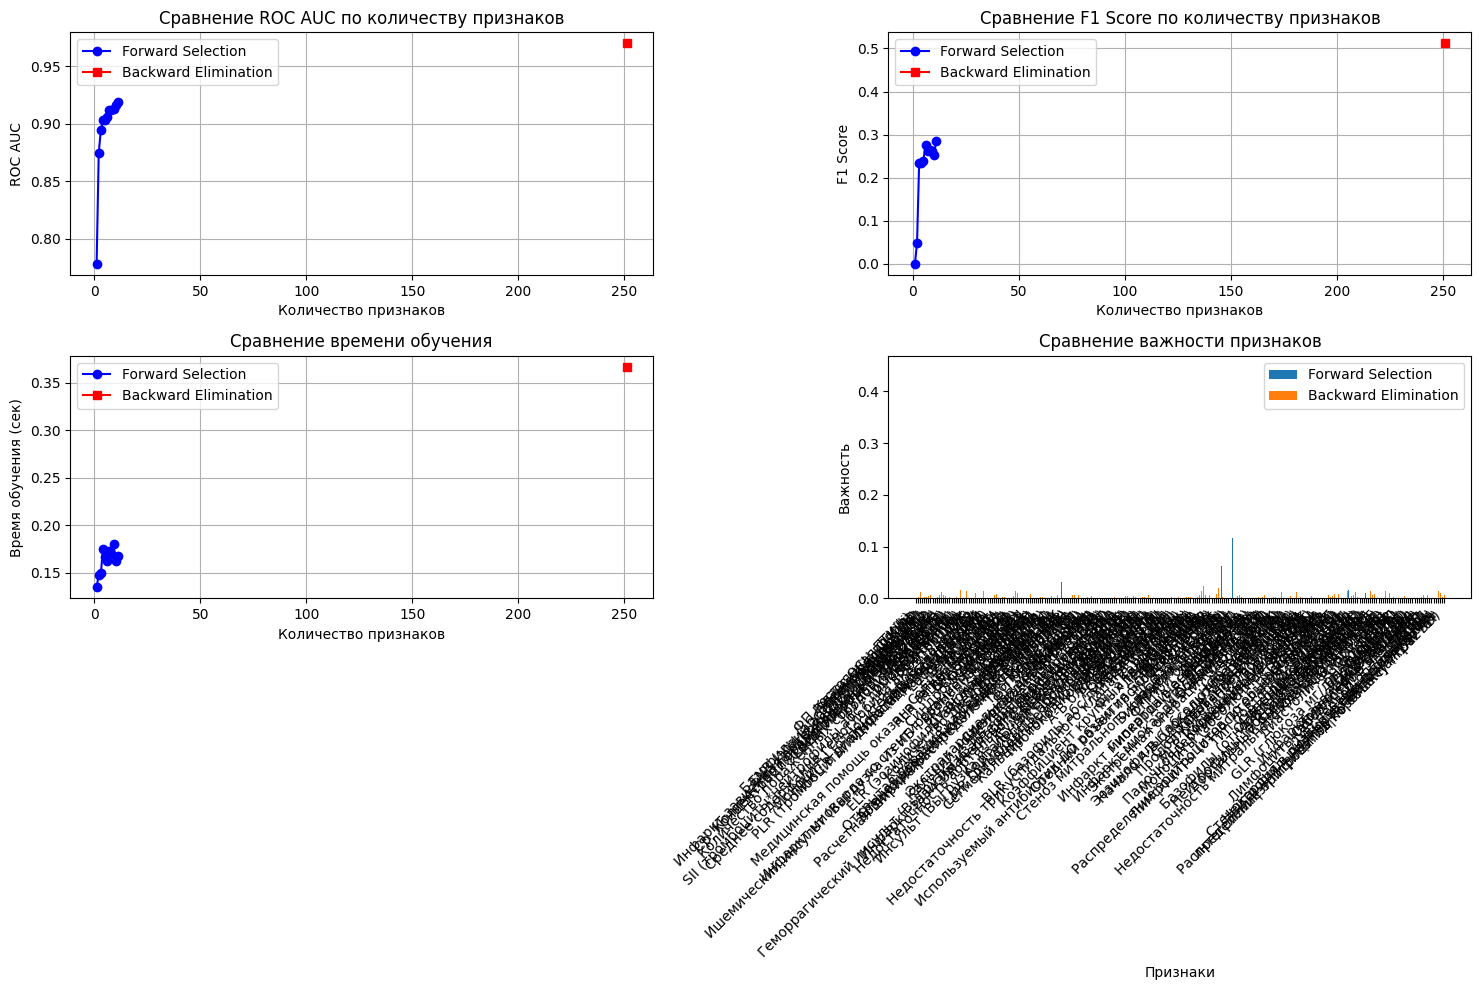


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (forward, 11 признаков) ===
По F1 score: 0.1500 (F1=0.4278)
По Youden's J: 0.0200

=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


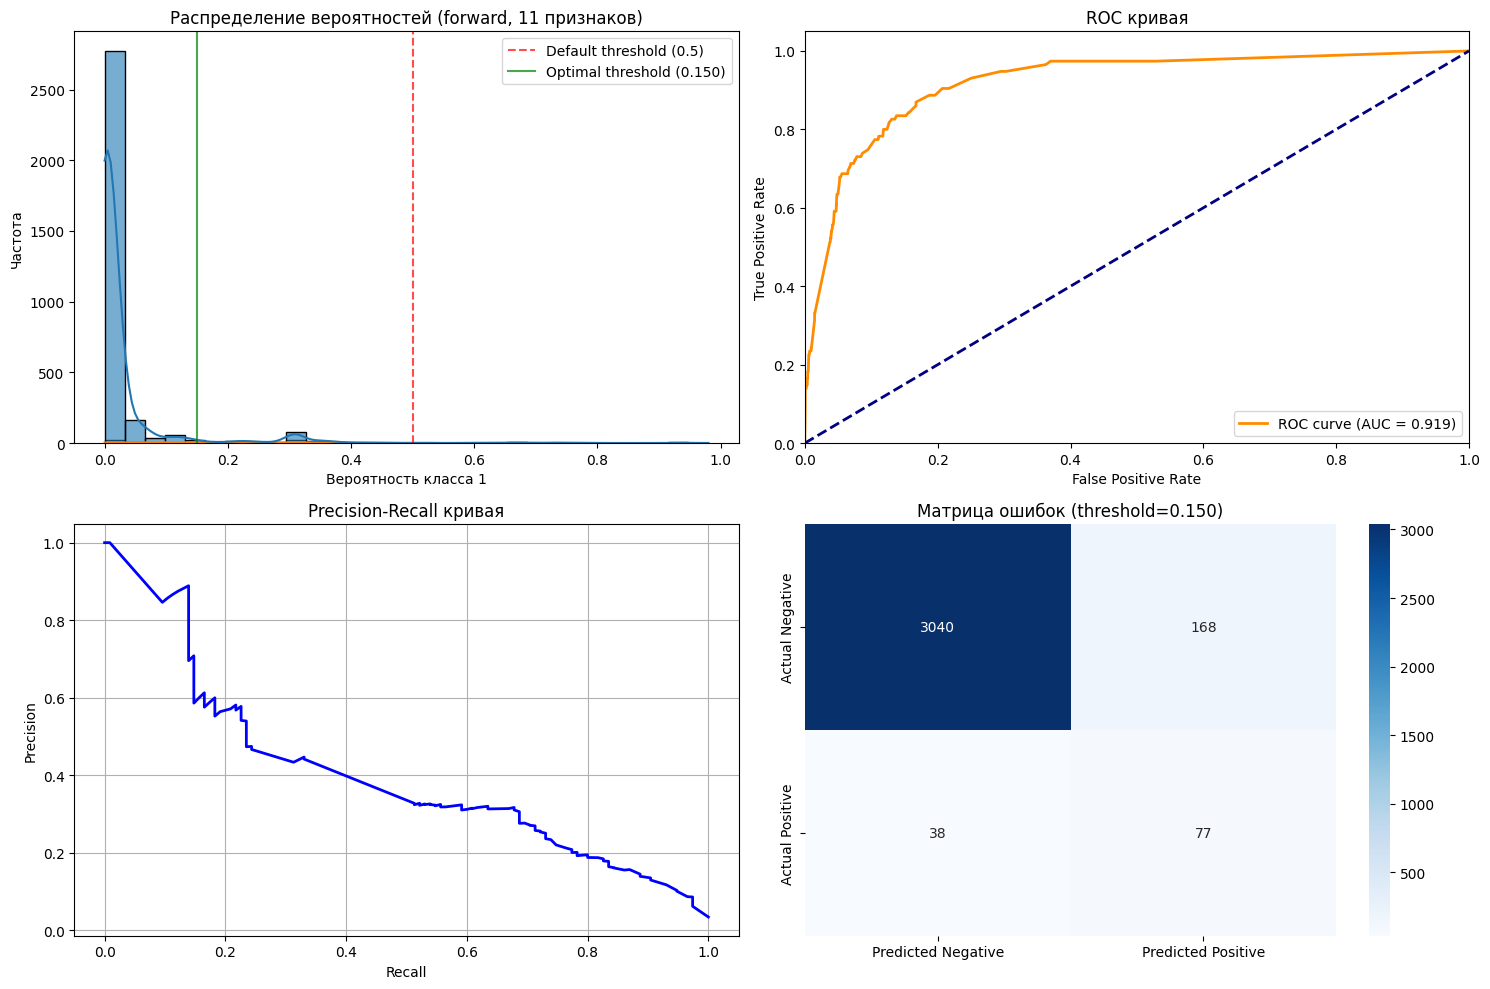

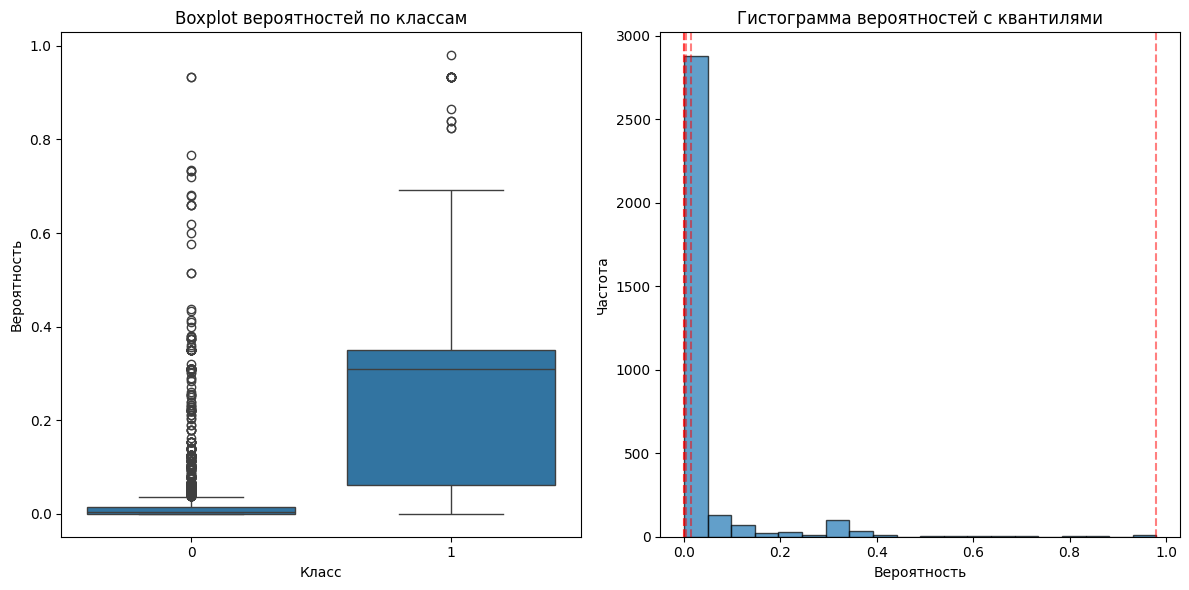


=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===
=== Лучшие признаки (forward) ===
Количество признаков: 11
Лучшая roc_auc: 0.9188
Признаки: ['СДЛА', 'UA (нестабильная стенокардия)', 'Количество дней в реанимации', 'Лимфоциты(%)(b)', 'А-В блокада (степень)', 'ЯБ', 'Билирубин общий(b)', 'Коррекция А-В блокады', 'Исход А-В блокады', 'BNP (b)', 'Тип повторной операции']

Важность признаков:
  СДЛА: 0.4467
  Количество дней в реанимации: 0.2182
  Билирубин общий(b): 0.1178
  UA (нестабильная стенокардия): 0.0777
  ЯБ: 0.0626
  Исход А-В блокады: 0.0324
  Тип повторной операции: 0.0170
  Коррекция А-В блокады: 0.0097
  А-В блокада (степень): 0.0095
  Лимфоциты(%)(b): 0.0082
  BNP (b): 0.0000
=== Лучшие признаки (backward) ===
Количество признаков: 251
Лучшая roc_auc: 0.9699
Признаки: ['Age', 'Sex', 'STEMI', 'ЧКВ', 'Вид STEMI', 'Инфаркт-зависимая артерия', 'Поражение ствола', 'Количество пораженных сосудов(Syntax)', 'Количество пораженных сосудов(Значимость)', 'TIMI', 'Инфаркт миокарда в анамнезе

In [13]:
# Инициализация анализатора
analyzer = FeatureSelectionAnalyzer(X, y, test_size=0.2, random_state=42)

# Выбор модели
model_rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)  # уменьшено количество деревьев для скорости

# Запуск forward selection БЕЗ early stopping
print("=== FORWARD SELECTION (без early stopping) ===")
forward_features = analyzer.forward_selection(model_rf, max_features=None)  # ограничим до 10 признакей для демонстрации

# Запуск backward elimination БЕЗ early stopping
print("\n=== BACKWARD ELIMINATION (без early stopping) ===")
backward_features = analyzer.backward_elimination(model_rf, min_features=1)

# Сравнение методов
print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
analyzer.compare_feature_selection_methods()

# Поиск оптимального порога для лучшей модели forward selection
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='forward')

# Визуализация распределения вероятностей
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='forward')

# Получение лучших признакей из всех комбинаций
print("\n=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===")
best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')

# Сохранение результатов
print("\n=== СОХРАНЕНИЕ РЕЗУЛЬТАТОВ ===")
analyzer.save_results_to_excel('feature_selection_analysis_full.xlsx')

print("\n=== ЗАКЛЮЧЕНИЕ ===")
print(f"Лучший ROC AUC (Forward): {best_forward_result['metrics']['roc_auc']:.4f} с {len(best_forward_features)} признаками")
print(f"Лучший ROC AUC (Backward): {best_backward_result['metrics']['roc_auc']:.4f} с {len(best_backward_features)} признаками")
print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")

----------------

In [14]:
scale_pos_weight = len(y[y == 0]) / max(1, len(y[y == 1]))
class_weight_dict = {0: 1, 1: scale_pos_weight}

print(scale_pos_weight)
print(class_weight_dict)

27.89217391304348
{0: 1, 1: 27.89217391304348}


In [16]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import lightgbm

In [17]:
# Инициализация анализатора
analyzer = FeatureSelectionAnalyzer(X, y, test_size=0.2, random_state=42)

# Выбор модели
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # борьба с дисбалансом
    missing=np.nan,  # явно указываем, что NaN - это пропуски
    random_state=42,
    eval_metric='logloss',  # для бинарной классификации
    tree_method='auto'  # автоматический выбор метода обучения
)  # уменьшено количество деревьев для скорости

# Запуск forward selection БЕЗ early stopping
print("=== FORWARD SELECTION (без early stopping) ===")
forward_features = analyzer.forward_selection(xgb_model, max_features=None)  # ограничим до 10 признакей для демонстрации

# Запуск backward elimination БЕЗ early stopping
print("\n=== BACKWARD ELIMINATION (без early stopping) ===")
backward_features = analyzer.backward_elimination(xgb_model, min_features=1)

# Сравнение методов
print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
analyzer.compare_feature_selection_methods()

# Поиск оптимального порога для лучшей модели forward selection
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='forward')

# Визуализация распределения вероятностей
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='forward')

# Получение лучших признакей из всех комбинаций
print("\n=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===")
best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')

# Сохранение результатов
print("\n=== СОХРАНЕНИЕ РЕЗУЛЬТАТОВ ===")
analyzer.save_results_to_excel('feature_selection_analysis_full.xlsx')

print("\n=== ЗАКЛЮЧЕНИЕ ===")
print(f"Лучший ROC AUC (Forward): {best_forward_result['metrics']['roc_auc']:.4f} с {len(best_forward_features)} признаками")
print(f"Лучший ROC AUC (Backward): {best_backward_result['metrics']['roc_auc']:.4f} с {len(best_backward_features)} признаками")
print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")

=== FORWARD SELECTION (без early stopping) ===
Запуск Forward Selection...


  0%|          | 0/252 [00:00<?, ?it/s]

ValueError: feature_names must be string, and may not contain [, ] or <

In [26]:
data["Смерть"]

0        0
1        0
2        0
3        0
4        1
        ..
17425    0
17426    0
17427    0
17428    0
17429    0
Name: Смерть, Length: 16613, dtype: int64

In [30]:
test = data[["Отек легких", "Смерть"]].dropna()

In [28]:
test

,СДЛА,Смерть
0,57.0,0
1,28.0,0
2,25.0,0
3,35.0,0
5,25.0,0
...,...,...
17425,30.0,0
17426,32.0,0
17427,25.0,0
17428,23.0,0


In [31]:
roc_auc_score(test["Смерть"], test["Отек легких"]) # ОСМ По киллип 3

0.22131833634249093

=== FORWARD SELECTION (без early stopping) ===
Запуск Forward Selection...



  0%|          | 1/252 [00:45<3:09:34, 45.32s/it, F1=0.4138, Features=1]

Step 1: Добавлен признак 'ФВ < 40', F1: 0.4138



  1%|          | 2/252 [01:30<3:07:39, 45.04s/it, F1=0.5432, Features=2]

Step 2: Добавлен признак 'Apache II', F1: 0.5432


...

Step 8: Нет улучшений, останавливаемся
Forward Selection завершен. Выбрано признаков: 7

=== BACKWARD ELIMINATION (без early stopping) ===
Запуск Backward Elimination...



  0%|          | 1/251 [01:41<7:01:50, 101.24s/it, F1=0.5896, Features=251]

Step 1: Удален признак 'Форма ФП', F1: 0.5896


  0%|          | 1/251 [03:24<14:10:06, 204.02s/it, F1=0.5896, Features=251]

Step 2: Удаление ухудшает результат, останавливаемся
Backward Elimination завершен. Осталось признаков: 251

=== СРАВНЕНИЕ МЕТОДОВ ===


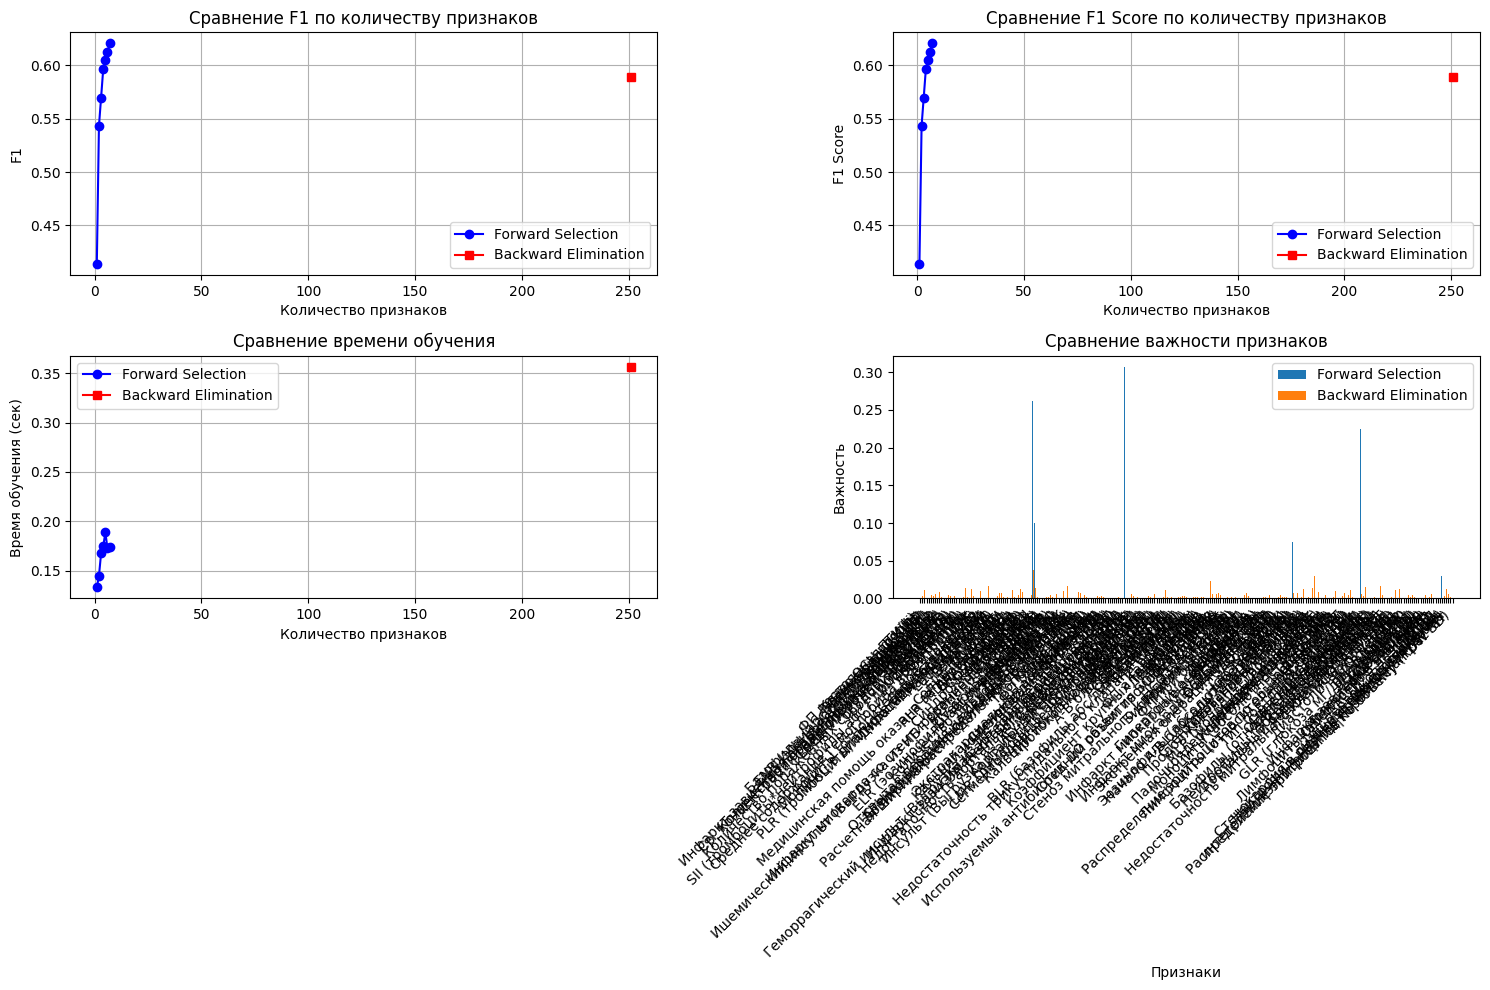


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (forward, 7 признаков) ===
По F1 score: 0.4300 (F1=0.6257)
По Youden's J: 0.0306

=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


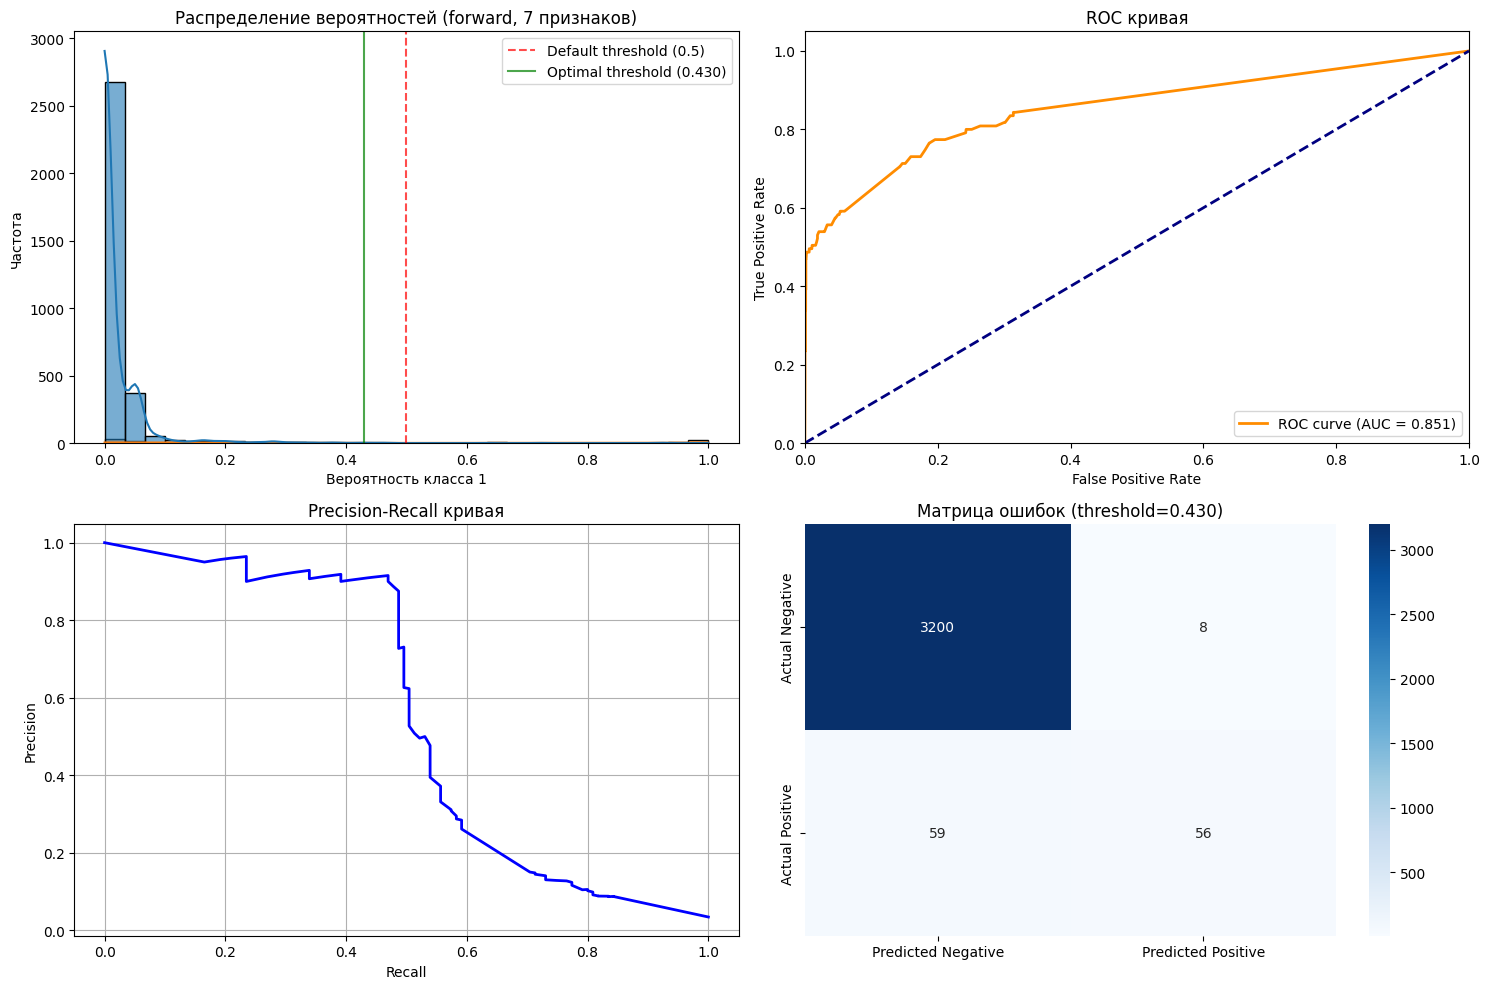

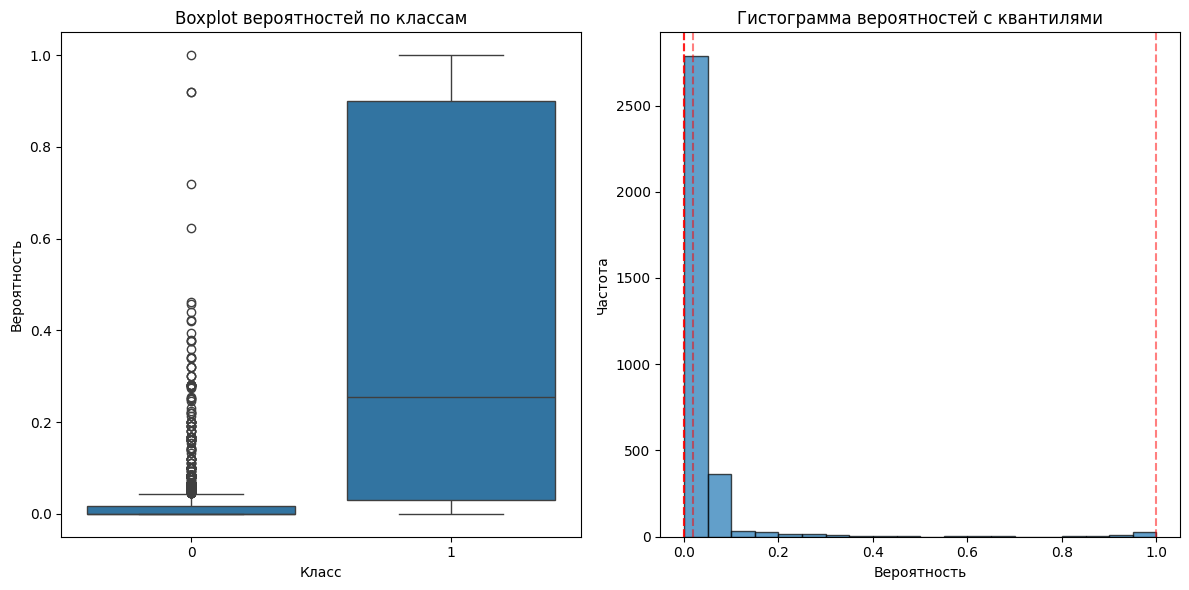


=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===
=== Лучшие признаки (forward) ===
Количество признаков: 7
Лучшая f1: 0.6207
Признаки: ['ФВ < 40', 'Apache II', 'Глюкоза в мг/дл', 'LACTartMax (b)', 'LACTartMax', 'Моноциты(%)(b)', 'Стеноз митрального клапана (степень)']

Важность признаков:
  ФВ < 40: 0.3065
  Apache II: 0.2620
  Глюкоза в мг/дл: 0.2247
  LACTartMax: 0.1005
  LACTartMax (b): 0.0743
  Моноциты(%)(b): 0.0303
  Стеноз митрального клапана (степень): 0.0018
=== Лучшие признаки (backward) ===
Количество признаков: 251
Лучшая f1: 0.5896
Признаки: ['Age', 'Sex', 'STEMI', 'ЧКВ', 'Вид STEMI', 'Инфаркт-зависимая артерия', 'Поражение ствола', 'Количество пораженных сосудов(Syntax)', 'Количество пораженных сосудов(Значимость)', 'TIMI', 'Инфаркт миокарда в анамнезе (<3)', 'Инфаркт миокарда в анамнезе (>3)', 'Инфаркт миокарда со стентированием в анамнезе', 'ОНМК (иш) в анамнезе', 'ОНМК (гем) в анамнезе', 'Стентирование в анамнезе', 'Тромболизис', 'Калий', 'Дилатация предсердий', 'ФП b (посл

In [35]:
# Инициализация анализатора
analyzer = FeatureSelectionAnalyzer(X, y, test_size=0.2, random_state=42)

# Выбор модели
model_rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)  # уменьшено количество деревьев для скорости

# Запуск forward selection БЕЗ early stopping
print("=== FORWARD SELECTION (без early stopping) ===")
forward_features = analyzer.forward_selection(model_rf, max_features=None)  # ограничим до 10 признакей для демонстрации

# Запуск backward elimination БЕЗ early stopping
print("\n=== BACKWARD ELIMINATION (без early stopping) ===")
backward_features = analyzer.backward_elimination(model_rf, min_features=1)

# Сравнение методов
print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
analyzer.compare_feature_selection_methods()

# Поиск оптимального порога для лучшей модели forward selection
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='forward')

# Визуализация распределения вероятностей
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='forward')

# Получение лучших признакей из всех комбинаций
print("\n=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===")
best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')

# Сохранение результатов
print("\n=== СОХРАНЕНИЕ РЕЗУЛЬТАТОВ ===")
analyzer.save_results_to_excel('feature_selection_analysis_full.xlsx')

print("\n=== ЗАКЛЮЧЕНИЕ ===")
print(f"Лучший f1 (Forward): {best_forward_result['metrics']['f1']:.4f} с {len(best_forward_features)} признаками")
print(f"Лучший f1 (Backward): {best_backward_result['metrics']['f1']:.4f} с {len(best_backward_features)} признаками")
print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("prepared_data.csv")

print(f"Данные успешно загружены! Размер: {df.shape}")
print(f"Занимаемая память: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Данные успешно загружены! Размер: (16613, 192)
Занимаемая память: 21.12 MB


In [5]:
X = df.drop(["target", "Отек легких"], axis=1)
y = df["target"]

In [6]:
def clean_column_names(df):
    """
    Очищает имена колонок от символов, которые не принимает XGBoost
    """
    new_columns = []
    for col in df.columns:
        # Удаляем запрещенные символы
        clean_col = col.replace('[', '_').replace(']', '_').replace('<', '_lt_')
        # Удаляем другие потенциально проблемные символы
        clean_col = clean_col.replace('>', '_gt_').replace(' ', '_').replace(':', '_')
        clean_col = clean_col.replace('(', '_').replace(')', '_').replace(',', '_')
        clean_col = clean_col.replace('{', '_').replace('}', '_').replace('|', '_')
        # Удаляем последовательные подчеркивания
        clean_col = '_'.join(filter(None, clean_col.split('_')))
        # Удаляем подчеркивания в начале и конце
        clean_col = clean_col.strip('_')
        # Если имя начинается с цифры, добавляем префикс
        if clean_col and clean_col[0].isdigit():
            clean_col = 'f_' + clean_col
        new_columns.append(clean_col)
    
    # Создаем копию DataFrame с новыми именами колонок
    df_clean = df.copy()
    df_clean.columns = new_columns
    return df_clean

# Применяем к вашим данным
X_clean = clean_column_names(X)

In [7]:
analyzer = FeatureSelectionAnalyzer(X_clean, y, test_size=0.2, random_state=42)

In [ ]:
# Запуск forward selection БЕЗ early stopping
print("=== FORWARD SELECTION (без early stopping) ===")
forward_features = analyzer.forward_selection(xgb_model, max_features=None)  # ограничим до 10 признакей для демонстрации

# Запуск backward elimination БЕЗ early stopping
print("\n=== BACKWARD ELIMINATION (без early stopping) ===")
backward_features = analyzer.backward_elimination(xgb_model, min_features=1)

# Сравнение методов
print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
analyzer.compare_feature_selection_methods()

# Поиск оптимального порога для лучшей модели forward selection
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='forward')

# Визуализация распределения вероятностей
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='forward')

# Получение лучших признакей из всех комбинаций
print("\n=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===")
best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')

# Сохранение результатов
print("\n=== СОХРАНЕНИЕ РЕЗУЛЬТАТОВ ===")
analyzer.save_results_to_excel('feature_selection_analysis_full.xlsx')

print("\n=== ЗАКЛЮЧЕНИЕ ===")
print(f"Лучший ROC AUC (Forward): {best_forward_result['metrics']['roc_auc']:.4f} с {len(best_forward_features)} признаками")
print(f"Лучший ROC AUC (Backward): {best_backward_result['metrics']['roc_auc']:.4f} с {len(best_backward_features)} признаками")
print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")

In [9]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import lightgbm
import time

In [10]:
scale_pos_weight = len(y[y == 0]) / max(1, len(y[y == 1]))
class_weight_dict = {0: 1, 1: scale_pos_weight}

print(f"scale pos weight: {scale_pos_weight}")

scale pos weight: 27.89217391304348


In [11]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # борьба с дисбалансом
    missing=np.nan,  # явно указываем, что NaN - это пропуски
    random_state=42,
    eval_metric='logloss',  # для бинарной классификации
    tree_method='auto'  # автоматический выбор метода обучения
)

In [17]:
lgb_model = LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    class_weight=class_weight_dict,  # борьба с дисбалансом
    random_state=42,
    verbose=-1,  # подавляем вывод (задается при инициализации, а не в fit)
    # early_stopping_rounds=50  # задается при инициализации
)

In [13]:
cat_model = CatBoostClassifier(
    iterations=100,
    depth=5,
    learning_rate=0.1,
    class_weights=[1, scale_pos_weight],  # борьба с дисбалансом
    random_state=42,
    verbose=False,
    eval_metric='Logloss',
    early_stopping_rounds=50  # задается при инициализации
)

# XGB

### XGB Forward selection

In [12]:
print("=== FORWARD SELECTION ===")
forward_features = analyzer.forward_selection(xgb_model, max_features=None, metric='f1')  # ограничим до 10 признакей для демонстрации

=== FORWARD SELECTION ===
Запуск Forward Selection...


  1%|          | 1/190 [22:12<69:58:20, 1332.81s/it, f1=0.2924, Features=1]

Step 1: Добавлен признак 'Отек_легких_a', f1: 0.2924


  1%|          | 2/190 [48:22<76:52:37, 1472.12s/it, f1=0.3183, Features=2]

Step 2: Добавлен признак 'Гипертоническая_болезнь', f1: 0.3183


...

Step 14: Добавлен признак 'Поражение_ствола', f1: 0.4673


  8%|▊         | 15/190 [6:40:40<77:28:34, 1593.80s/it, f1=0.4873, Features=15]

Step 15: Добавлен признак 'Сопутствующие1_freq', f1: 0.4873


  8%|▊         | 15/190 [7:06:47<82:59:16, 1707.18s/it, f1=0.4873, Features=15]

Step 16: Нет улучшений, останавливаемся
Forward Selection завершен. Выбрано признаков: 15


### XGB Backward elimination

In [ ]:
print("\n=== BACKWARD ELIMINATION ===")
backward_features = analyzer.backward_elimination(xgb_model, min_features=1, metric='f1')

In [17]:
print("Hello world")

Hello world


In [18]:
backward_features

['Unnamed_0',
 'Age',
 'Sex',
 'STEMI',
 'ЧКВ',
 'Вид_STEMI',
 'Поражение_ствола',
 'Количество_пораженных_сосудов_Значимость',
 'TIMI',
 'Инфаркт_миокарда_в_анамнезе_lt_3',
 'Инфаркт_миокарда_в_анамнезе_gt_3',
 'Инфаркт_миокарда_со_стентированием_в_анамнезе',
 'ОНМК_иш_в_анамнезе',
 'Тромболизис',
 'ФП_a_в_анамнезе',
 'ГБ_риск',
 'Стенокардия_ИБ',
 'СД',
 'ХБП',
 'ЯБ',
 'МКБ',
 'ФВ_ЛЖ',
 'МЖП',
 'ЗСЛЖ',
 'ПСПЖ',
 'СДЛА',
 'Размер_правого_желудочка',
 'НПВ_диаметр',
 'La1',
 'La2',
 'Ra1',
 'Ra2',
 'Гематокрит',
 'Эритроциты',
 'Лейкоциты',
 'Тромбоциты',
 'Нейтрофилы_относительное_значение',
 'Лимфоциты_абсолютное_значение',
 'Лимфоциты_относительное_значение',
 'Моноциты_абсолютное_значение',
 'Моноциты_относительное_значение',
 'Эозинофилы_абсолютное_значение',
 'Эозинофилы_относительное_значение',
 'Базофилы_относительное_значение',
 'Сумма_всех_лейкоцитов',
 'Средний_объем_эритроцита',
 'Ср_концентрация_гемоглобина_в_эритроците',
 'Распределение_эритроцитов_по_объему_RDW-CV',
 'Ра


=== СРАВНЕНИЕ МЕТОДОВ ===


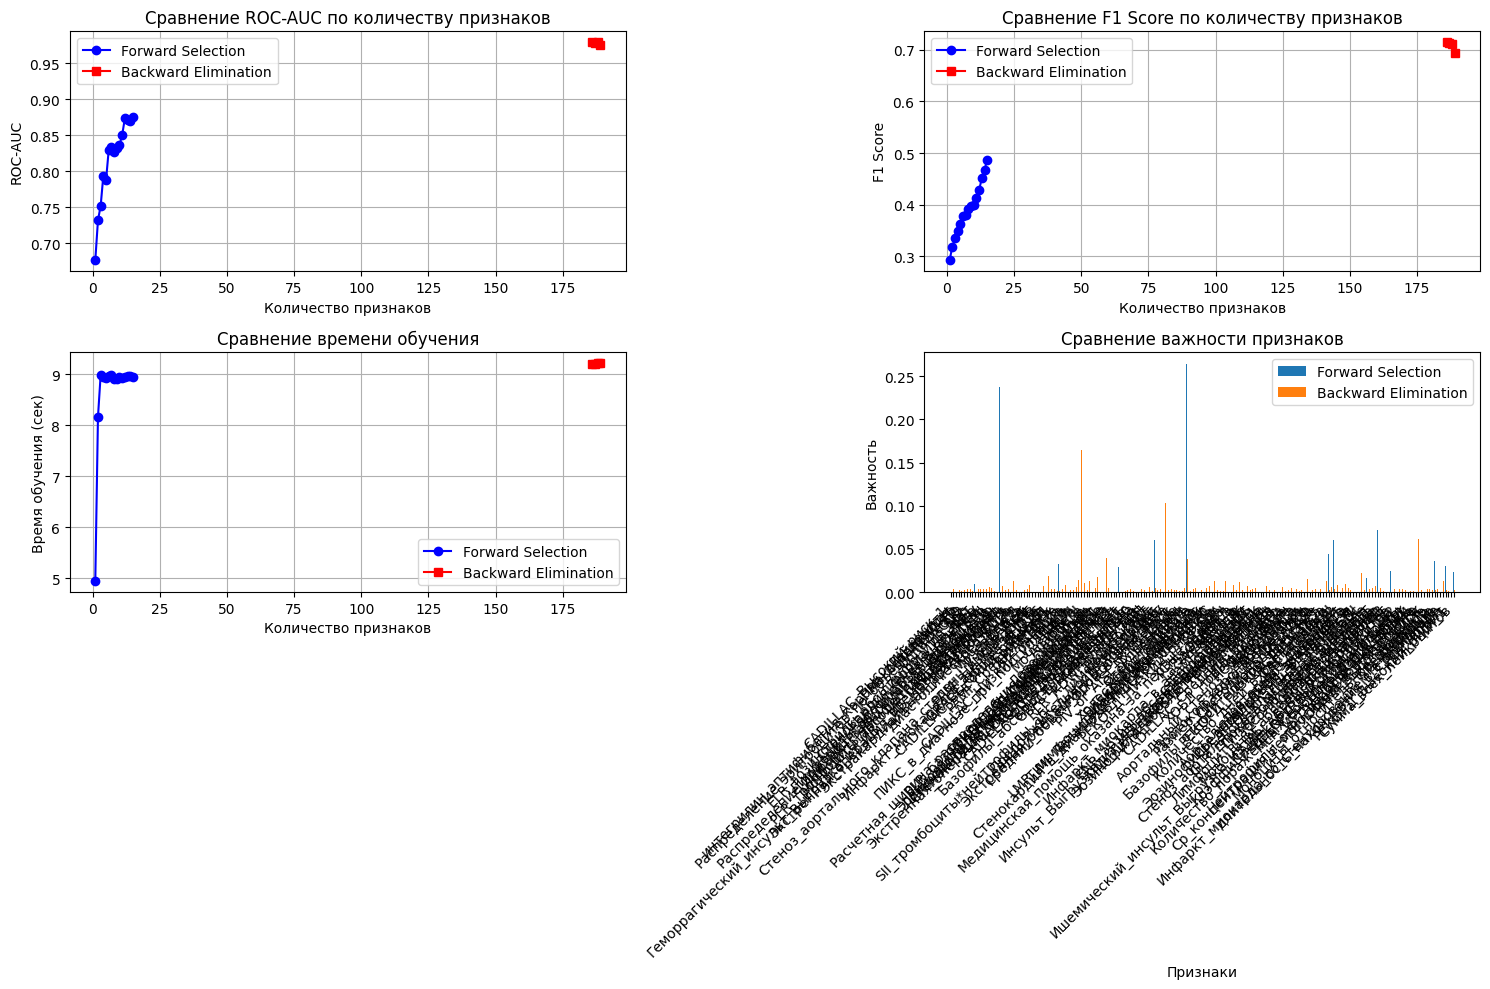

In [19]:
print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
analyzer.compare_feature_selection_methods()

In [20]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='forward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (forward, 15 признаков) ===
По F1 score: 0.7900 (F1=0.5405)
По Youden's J: 0.5017


In [21]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='backward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (backward, 186 признаков) ===
По F1 score: 0.5400 (F1=0.7149)
По Youden's J: 0.0331



=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


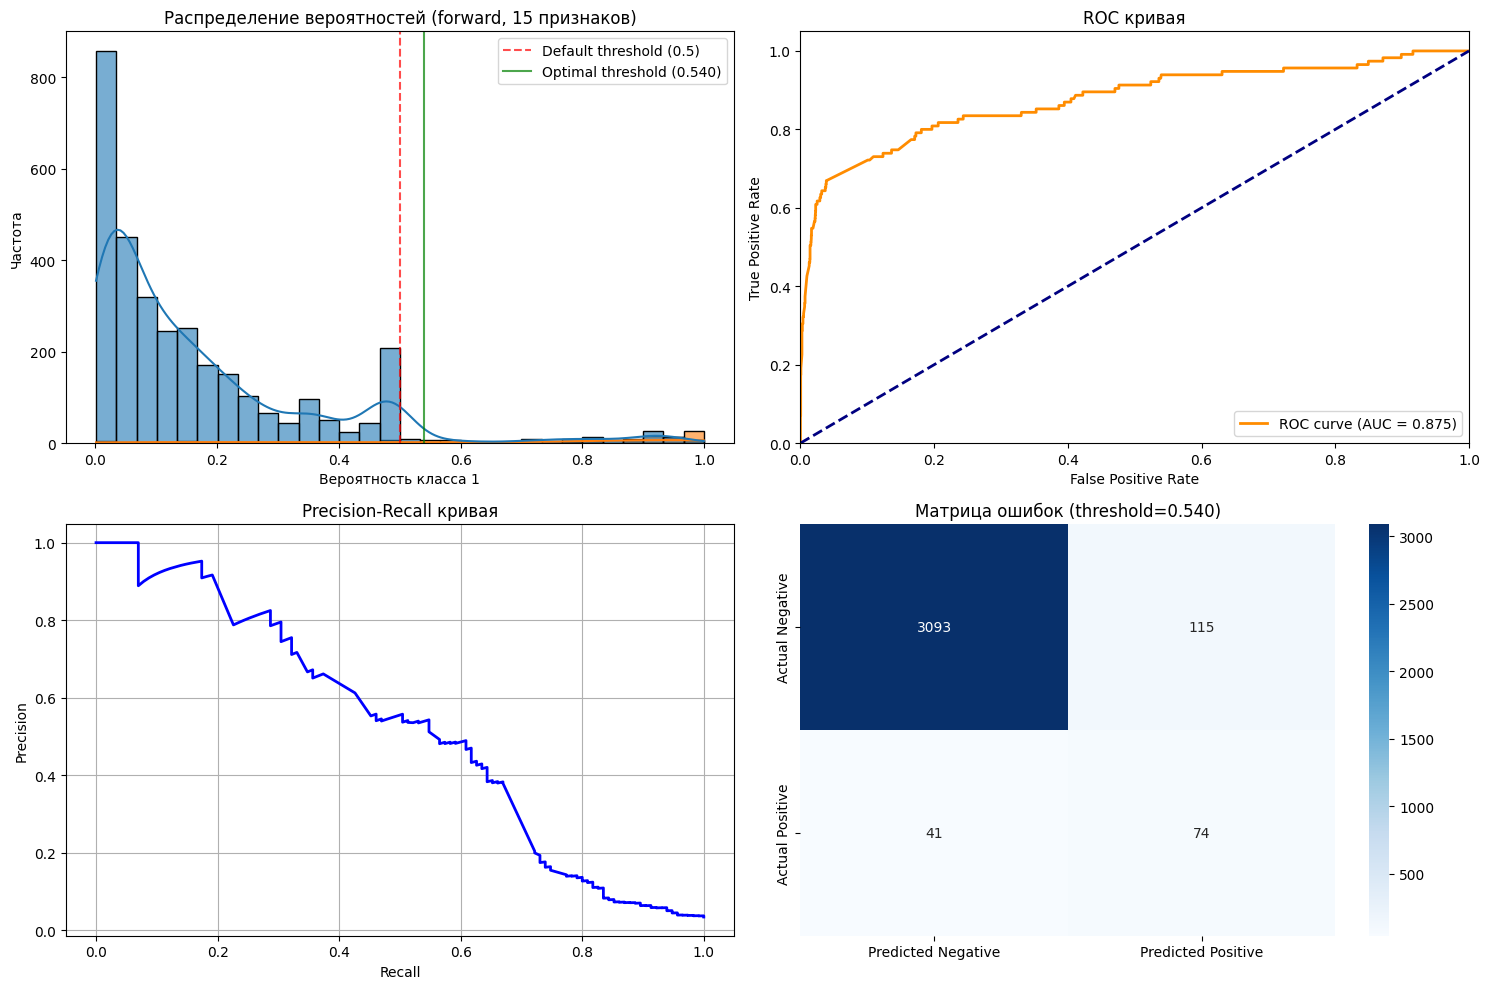

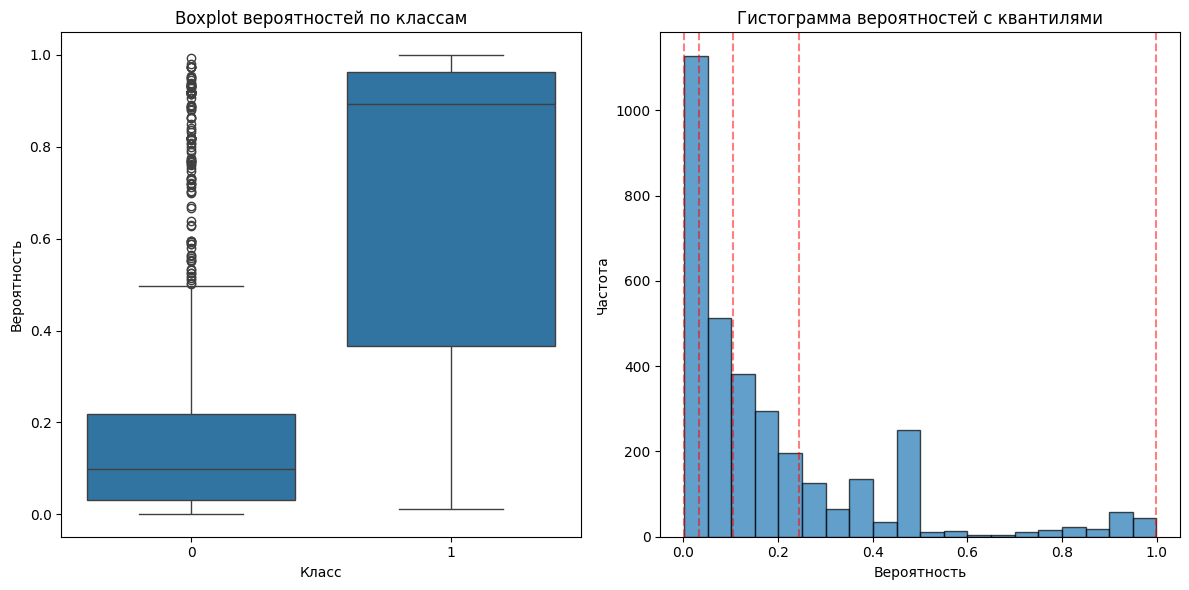

In [22]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='forward')


=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


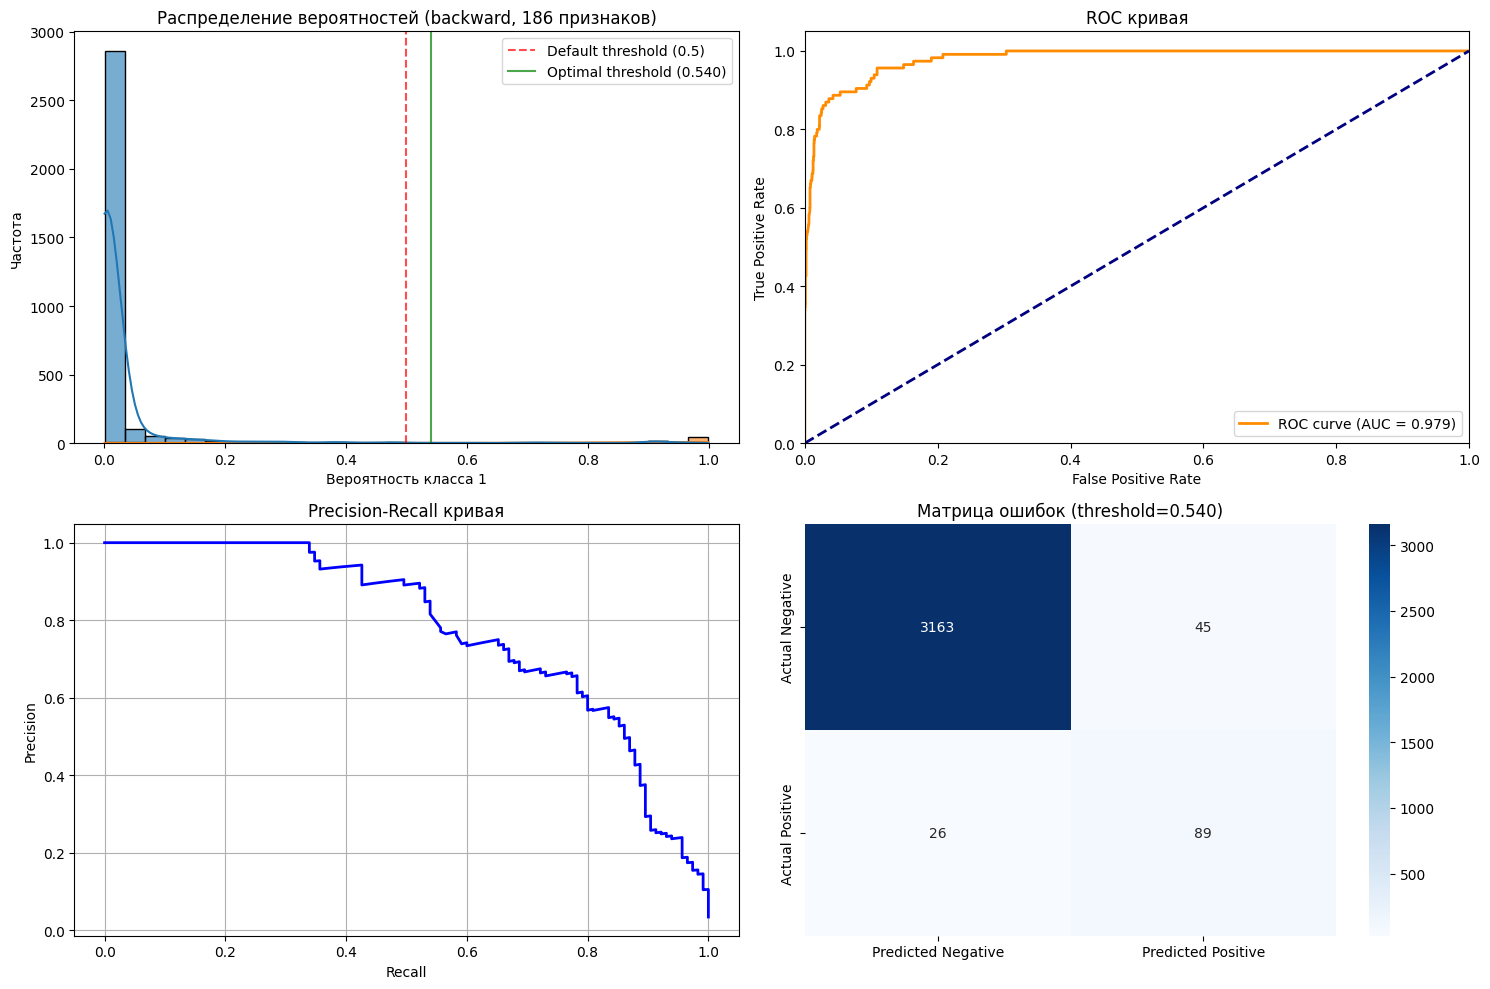

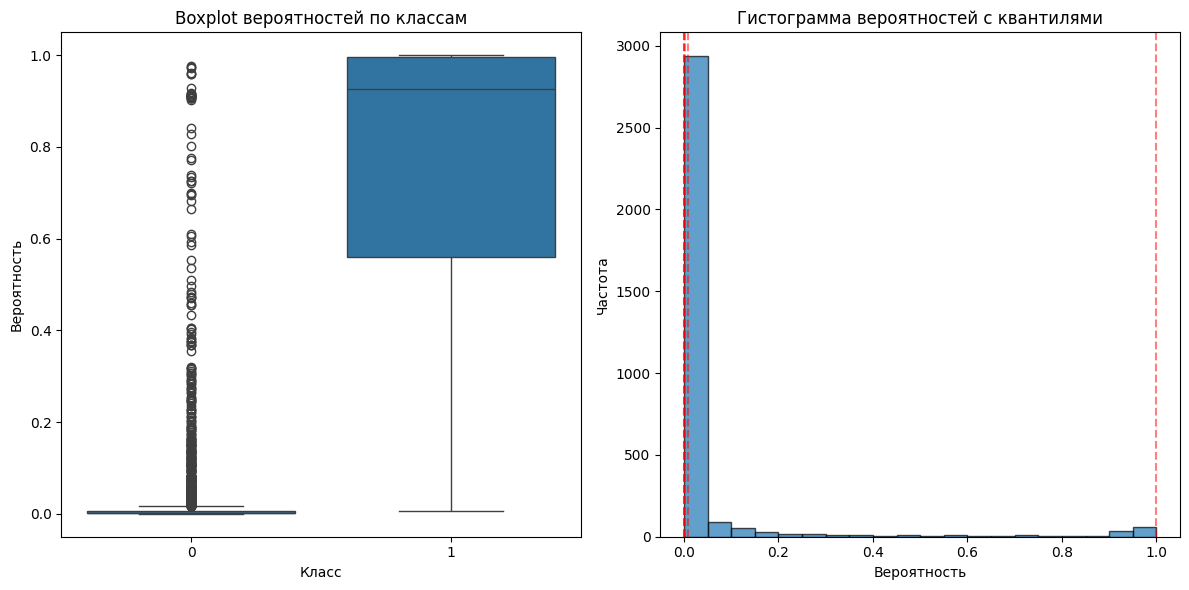

In [23]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='backward')

In [24]:
# Получение лучших признакей из всех комбинаций
print("\n=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===")
best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')


=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===
=== Лучшие признаки (forward) ===
Количество признаков: 15
Лучшая f1: 0.4873
Признаки: ['Отек_легких_a', 'Гипертоническая_болезнь', 'Адреналин', 'LACTartMin_a', 'PO2VenMin', 'Сумма_всех_лейкоцитов', 'CADILLAC_Высокий_риск_Нет', 'pHARTmin_a', 'Стенокардия_форма_ИБ_Нет', 'pO2ARTmax', 'Норадреналин', 'SII_тромбоциты*нейтрофилы_абс_/_лимфоциты_абс', 'ТВ_a', 'Поражение_ствола', 'Сопутствующие1_freq']

Важность признаков:
  Отек_легких_a: 0.2649
  Норадреналин: 0.2373
  Поражение_ствола: 0.0717
  SII_тромбоциты*нейтрофилы_абс_/_лимфоциты_абс: 0.0607
  Адреналин: 0.0603
  LACTartMin_a: 0.0600
  ТВ_a: 0.0443
  pHARTmin_a: 0.0355
  pO2ARTmax: 0.0319
  PO2VenMin: 0.0305
  Сопутствующие1_freq: 0.0295
  CADILLAC_Высокий_риск_Нет: 0.0243
  Сумма_всех_лейкоцитов: 0.0235
  Гипертоническая_болезнь: 0.0164
  Стенокардия_форма_ИБ_Нет: 0.0090
=== Лучшие признаки (backward) ===
Количество признаков: 186
Лучшая f1: 0.7143
Признаки: ['Unnamed_0', 'Age', 'Sex', 'ST

In [25]:
print("\n=== СОХРАНЕНИЕ РЕЗУЛЬТАТОВ ===")
analyzer.save_results_to_excel('xgb_3.xlsx')


=== СОХРАНЕНИЕ РЕЗУЛЬТАТОВ ===
Результаты успешно сохранены в файл: xgb_3.xlsx


In [26]:
print("\n=== ЗАКЛЮЧЕНИЕ ===")
print(f"Лучший ROC AUC (Forward): {best_forward_result['metrics']['roc_auc']:.4f} с {len(best_forward_features)} признаками")
print(f"Лучший ROC AUC (Backward): {best_backward_result['metrics']['roc_auc']:.4f} с {len(best_backward_features)} признаками")
print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")


=== ЗАКЛЮЧЕНИЕ ===
Лучший ROC AUC (Forward): 0.8754 с 15 признаками
Лучший ROC AUC (Backward): 0.9793 с 186 признаками
Оптимальный порог для бинарной классификации: 0.5400


# LGB

In [16]:
analyzer = FeatureSelectionAnalyzer(X_clean, y, test_size=0.2, random_state=42)

In [ ]:
print("=== FORWARD SELECTION ===")
forward_features = analyzer.forward_selection(lgb_model, max_features=None, metric='f1')  # ограничим до 10 признакей для демонстрации

=== FORWARD SELECTION ===
Запуск Forward Selection...



  1%|          | 1/190 [27:10<85:36:02, 1630.49s/it, f1=0.2924, Features=1]

Step 1: Добавлен признак 'Отек_легких_a', f1: 0.2924



  1%|          | 2/190 [1:05:37<105:56:05, 2028.54s/it, f1=0.3183, Features=2]

Step 2: Добавлен признак 'Гипертоническая_болезнь', f1: 0.3183


...

Step 7: Добавлен признак 'Норадреналин', f1: 0.3588



  4%|▍         | 8/190 [6:25:17<161:49:36, 3200.97s/it, f1=0.3636, Features=8]

Step 8: Добавлен признак 'ХСН_стадия_II', f1: 0.3636



  5%|▍         | 9/190 [7:22:50<164:53:37, 3279.65s/it, f1=0.3707, Features=9]

Step 9: Добавлен признак 'Apache_II', f1: 0.3707


In [24]:
1

1

In [22]:
print("\n=== BACKWARD ELIMINATION ===")
backward_features = analyzer.backward_elimination(lgb_model, min_features=1, metric='f1')


=== BACKWARD ELIMINATION ===
Запуск Backward Elimination...



  1%|          | 1/189 [1:11:55<225:22:24, 4315.66s/it, f1=0.6875, Features=189]

Step 1: Удален признак 'Нейтрофилы_абсолютное_значение_a', f1: 0.6875



  1%|          | 2/189 [2:24:34<225:29:07, 4340.90s/it, f1=0.6980, Features=188]

Step 2: Удален признак 'SaO2min_a', f1: 0.6980



  2%|▏         | 3/189 [3:36:32<223:45:02, 4330.66s/it, f1=0.7063, Features=187]

Step 3: Удален признак 'SII_тромбоциты*нейтрофилы_абс_/_лимфоциты_абс', f1: 0.7063


  2%|▏         | 3/189 [4:48:19<297:56:35, 5766.64s/it, f1=0.7063, Features=187]

Step 4: Удаление ухудшает результат, останавливаемся
Backward Elimination завершен. Осталось признаков: 187



=== СРАВНЕНИЕ МЕТОДОВ ===


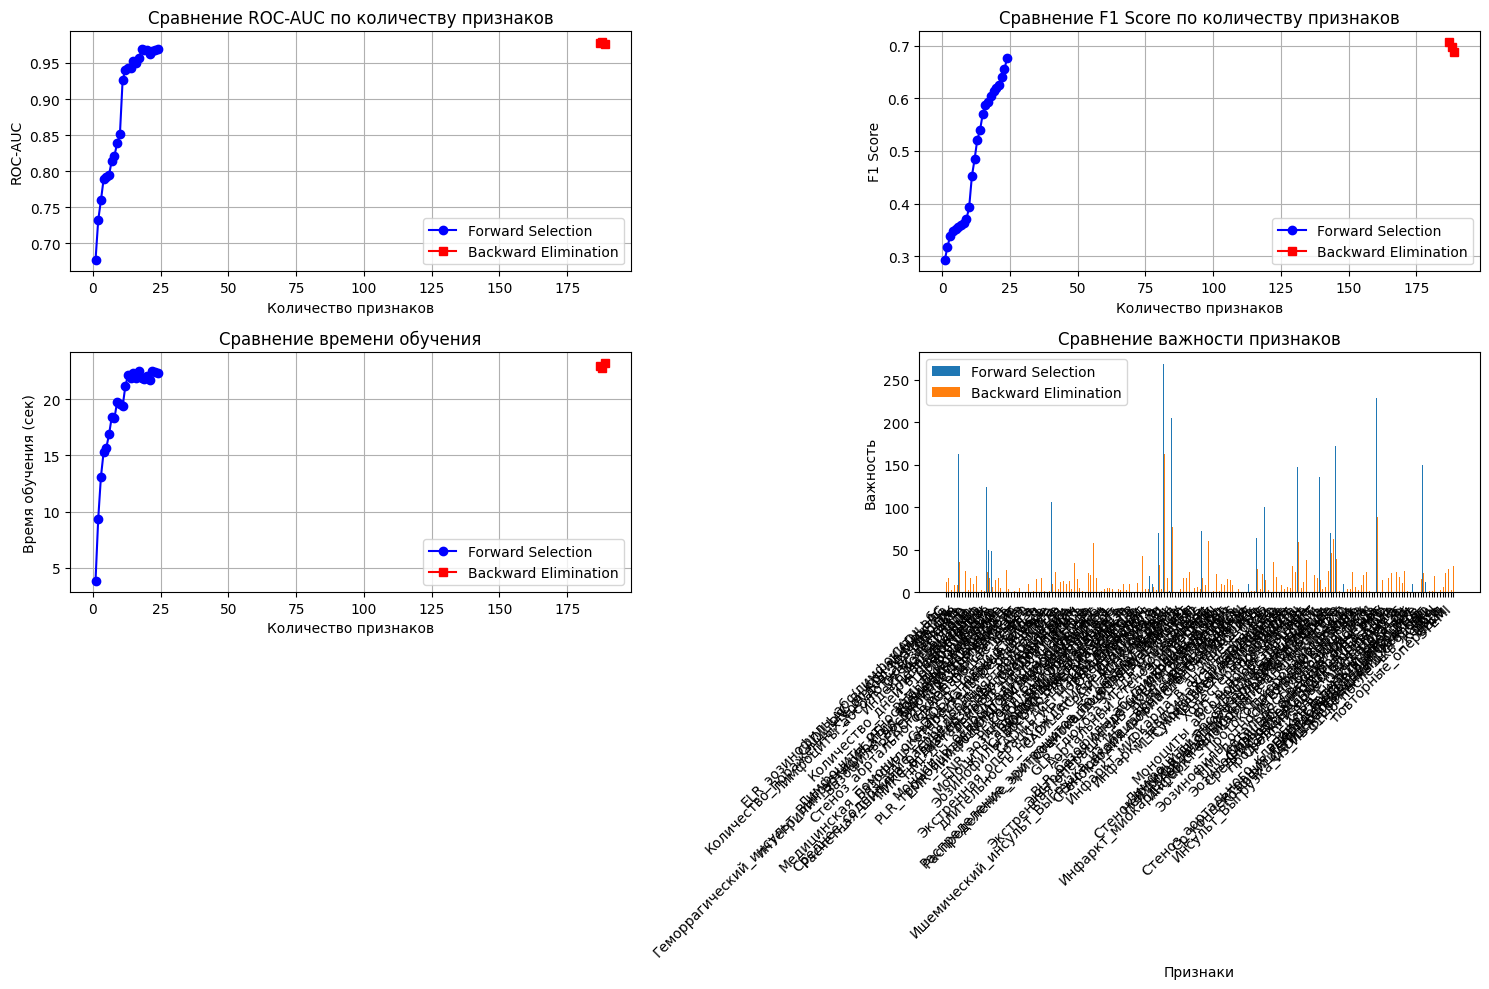

In [25]:
print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
analyzer.compare_feature_selection_methods()

In [ ]:
print("Hello world")

In [26]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='forward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (forward, 24 признаков) ===
По F1 score: 0.6700 (F1=0.6844)
По Youden's J: 0.3464


In [27]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='backward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (backward, 187 признаков) ===
По F1 score: 0.5000 (F1=0.7063)
По Youden's J: 0.0751



=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


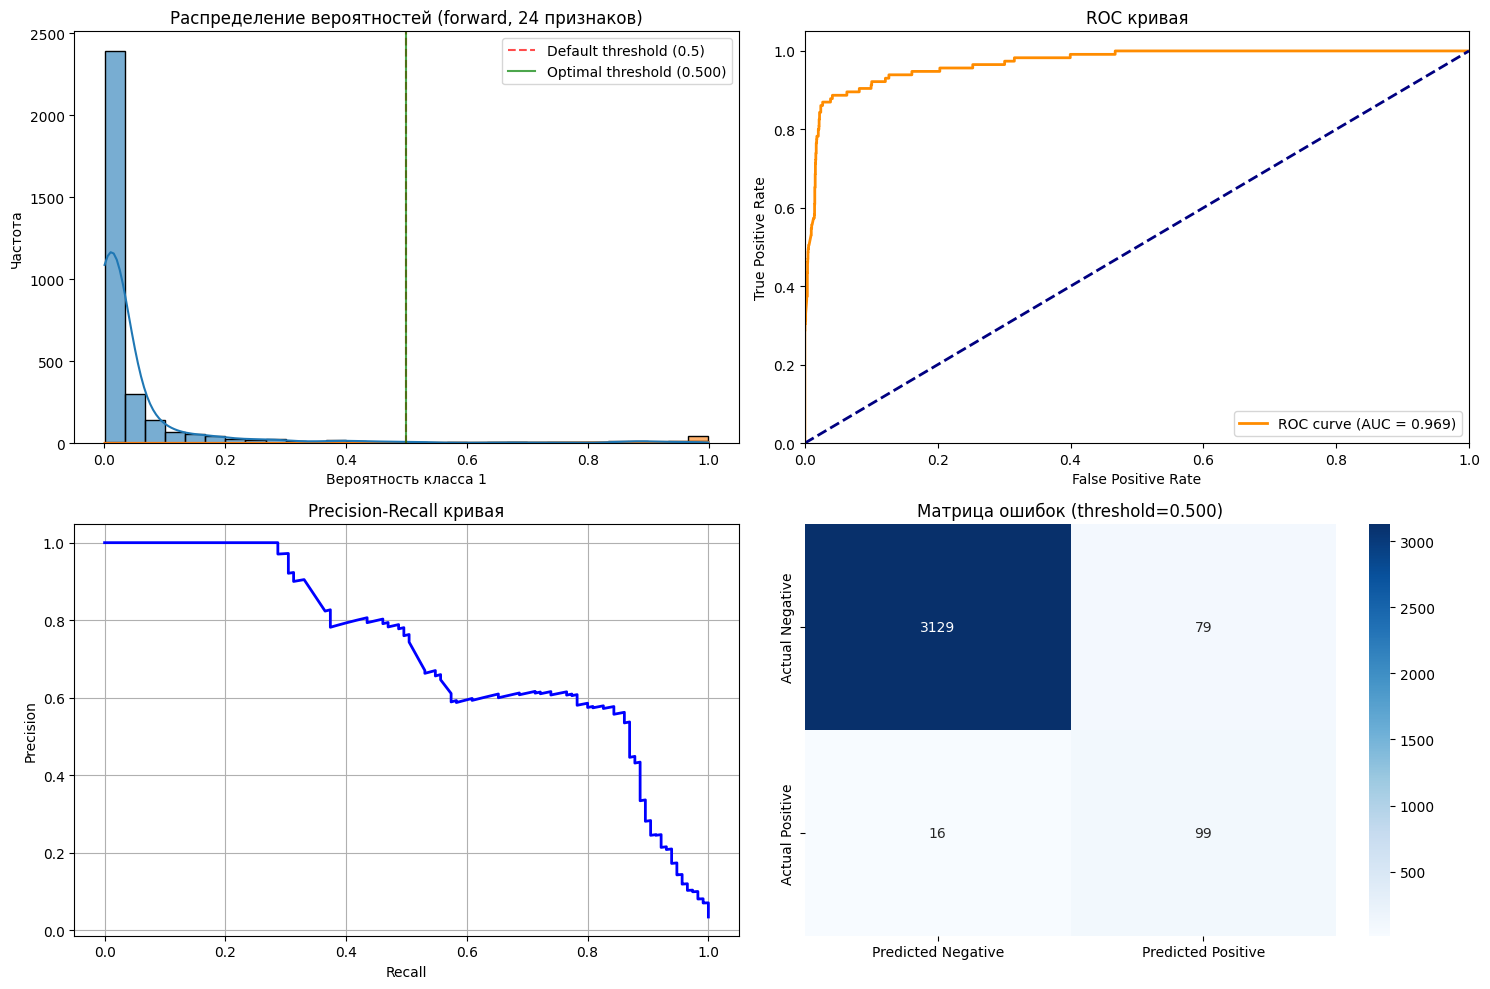

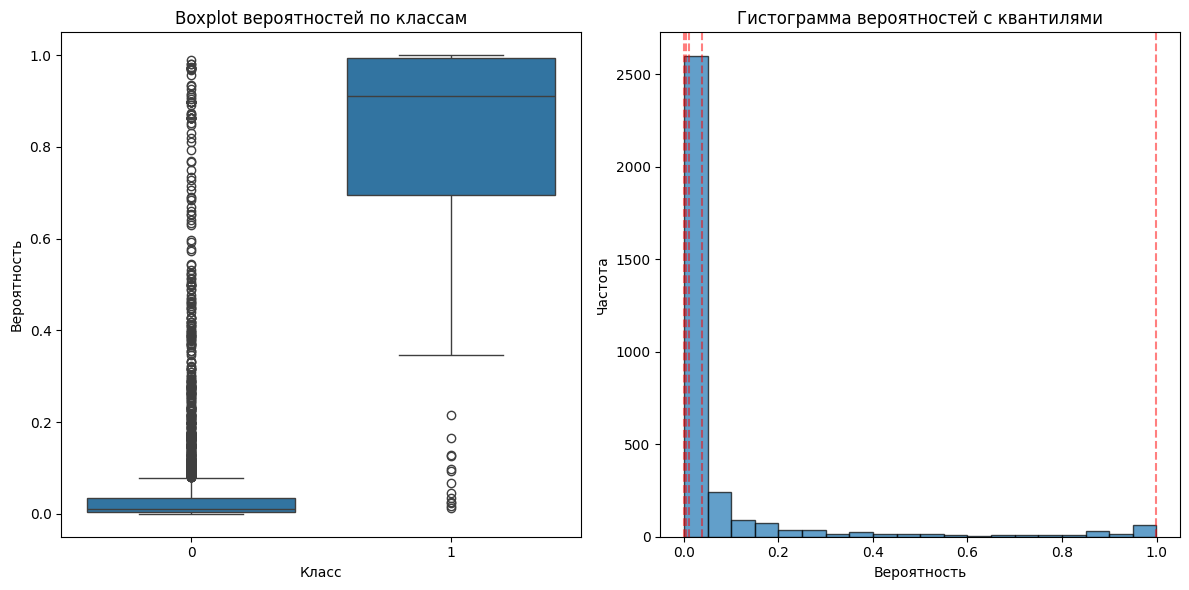

In [28]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='forward')


=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


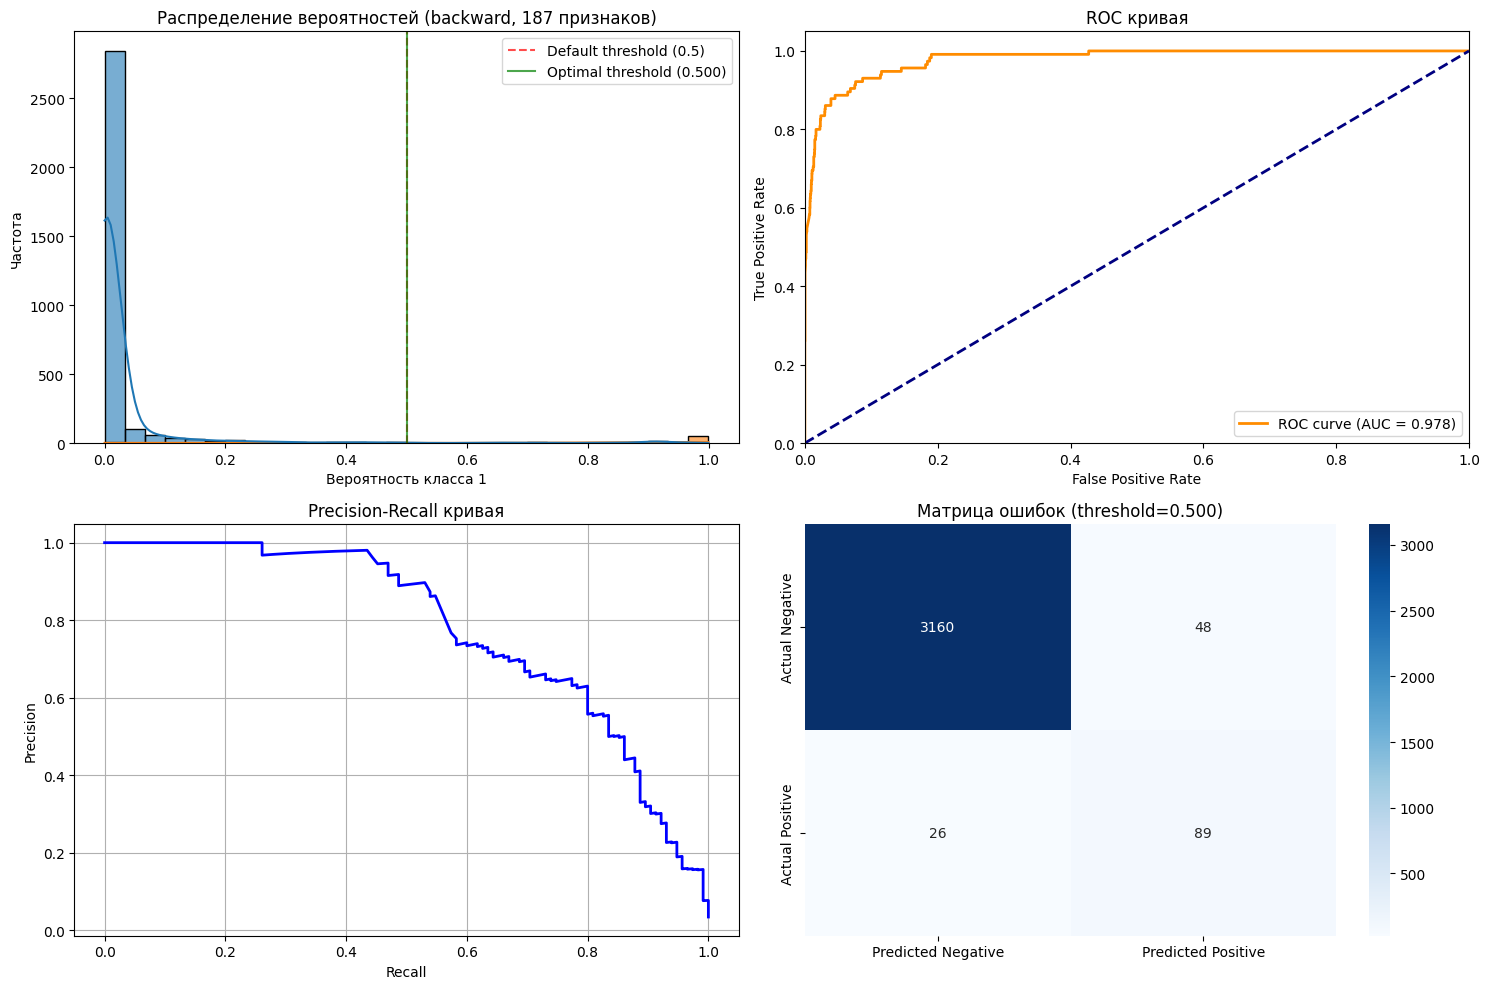

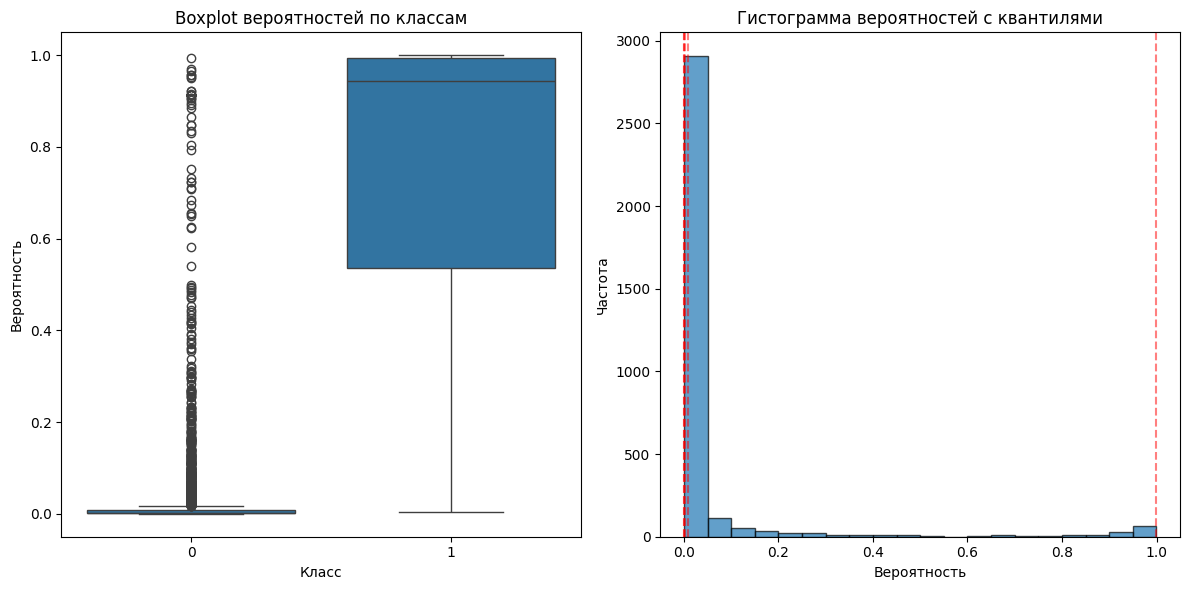

In [29]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='backward')

In [32]:
# Получение лучших признакей из всех комбинаций
print("\n=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===")
best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')


=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===
=== Лучшие признаки (forward) ===
Количество признаков: 24
Лучшая f1: 0.6758
Признаки: ['Отек_легких_a', 'Гипертоническая_болезнь', 'Адреналин', 'РЕКОРД_Низкий_риск_Да', 'Экстренная_операция_ИБ_Новый_Плановая', 'Инфаркт_миокарда_в_анамнезе_lt_3', 'Норадреналин', 'ХСН_стадия_II', 'Apache_II', 'Количество_дней_в_реанимации', 'длительность_нахождения_в_стационаре', 'MKB_freq', 'GRACE_Общее', 'СДЛА', 'Коэффициент_крупных_тромбоцитов', 'MPV/PC_MPV/_PLT', 'Стенокардия_в_диагнозе_при_поступлении', 'Базофилы_относительное_значение', 'Ra1', 'CADILLAC_Средний_риск_1', 'ФВ_ЛЖ', 'Стенокардия_ИБ', 'ЗСЛЖ', 'SpO2']

Важность признаков:
  длительность_нахождения_в_стационаре: 269.0000
  Apache_II: 229.0000
  MKB_freq: 205.0000
  GRACE_Общее: 172.0000
  ФВ_ЛЖ: 163.0000
  Коэффициент_крупных_тромбоцитов: 149.0000
  СДЛА: 147.0000
  MPV/PC_MPV/_PLT: 136.0000
  Количество_дней_в_реанимации: 124.0000
  Базофилы_относительное_значение: 106.0000
  Ra1: 100.0000
  S

In [33]:
print("\n=== СОХРАНЕНИЕ РЕЗУЛЬТАТОВ ===")
analyzer.save_results_to_excel('lgb_2.xlsx')


=== СОХРАНЕНИЕ РЕЗУЛЬТАТОВ ===
Результаты успешно сохранены в файл: lgb_2.xlsx


In [34]:
print("\n=== ЗАКЛЮЧЕНИЕ ===")
print(f"Лучший ROC AUC (Forward): {best_forward_result['metrics']['roc_auc']:.4f} с {len(best_forward_features)} признаками")
print(f"Лучший ROC AUC (Backward): {best_backward_result['metrics']['roc_auc']:.4f} с {len(best_backward_features)} признаками")
print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")


=== ЗАКЛЮЧЕНИЕ ===
Лучший ROC AUC (Forward): 0.9693 с 24 признаками
Лучший ROC AUC (Backward): 0.9777 с 187 признаками
Оптимальный порог для бинарной классификации: 0.5000


# CatBoost

In [35]:
analyzer = FeatureSelectionAnalyzer(X_clean, y, test_size=0.2, random_state=42)

In [36]:
print("=== FORWARD SELECTION ===")
forward_features = analyzer.forward_selection(cat_model, max_features=None, metric='f1')  # ограничим до 10 признакей для демонстрации

=== FORWARD SELECTION ===
Запуск Forward Selection...



  3%|▎         | 5/190 [71:46:04<2655:24:56, 51672.95s/it, f1=0.3522, Features=5]


CatBoostError: catboost/libs/data/quantization.cpp:2420: All features are either constant or ignored.

In [37]:
table = pd.read_excel("lgb_2.xlsx")

In [38]:
table

,Method,Step,N_Features,Features,Accuracy,Precision,Recall,F1,ROC_AUC,Training_Time,...,Importance_Коэффициент_крупных_тромбоцитов,Importance_MPV/PC_MPV/_PLT,Importance_Стенокардия_в_диагнозе_при_поступлении,Importance_Базофилы_относительное_значение,Importance_Ra1,Importance_CADILLAC_Средний_риск_1,Importance_ФВ_ЛЖ,Importance_Стенокардия_ИБ,Importance_ЗСЛЖ,Importance_SpO2
0,Forward,1,1,Отек_легких_a,0.935901,0.236559,0.382609,0.292359,0.676194,3.819139,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Forward,2,2,"Отек_легких_a, Гипертоническая_болезнь",0.931688,0.243119,0.460870,0.318318,0.732004,9.368924,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Forward,3,3,"Отек_легких_a, Гипертоническая_болезнь, Адреналин",0.931688,0.254386,0.504348,0.338192,0.759570,13.096042,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Forward,4,4,"Отек_легких_a, Гипертоническая_болезнь, Адрена...",0.934698,0.266055,0.504348,0.348348,0.789049,15.308106,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Forward,5,5,"Отек_легких_a, Гипертоническая_болезнь, Адрена...",0.934698,0.268182,0.513043,0.352239,0.791727,15.691161,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Forward,6,6,"Отек_легких_a, Гипертоническая_болезнь, Адрена...",0.935600,0.271889,0.513043,0.355422,0.794866,16.874929,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Forward,7,7,"Отек_легких_a, Гипертоническая_болезнь, Адрена...",0.926873,0.257576,0.591304,0.358839,0.814542,18.417949,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Forward,8,8,"Отек_легких_a, Гипертоническая_болезнь, Адрена...",0.928378,0.262548,0.591304,0.363636,0.821552,18.331583,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Forward,9,9,"Отек_легких_a, Гипертоническая_болезнь, Адрена...",0.922359,0.257627,0.660870,0.370732,0.839078,19.777493,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Forward,10,10,"Отек_легких_a, Гипертоническая_болезнь, Адрена...",0.927475,0.276596,0.678261,0.392947,0.850913,19.527713,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
